In [1]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pylab as plt
import duckdb


sales_csv=r"C:/M5 Data/m5-forecasting-accuracy/sales_train_evaluation.csv"
calendar_csv=r"C:/M5 Data/m5-forecasting-accuracy/calendar.csv"
price_csv= r"C:/M5 Data/m5-forecasting-accuracy/sell_prices.csv"

sales_df=pd.read_csv(f"{sales_csv}")
sales_df=sales_df[(sales_df['store_id']=='TX_2') &(sales_df['item_id']=='FOODS_3_825') ]
print(sales_df['item_id'].unique())

['FOODS_3_825']


In [2]:



cols = sales_df.columns

day_cols = [c for c in cols if c.startswith("d_")]
print(f"Found {len(day_cols)} daily columns: {day_cols[:5]} ... {day_cols[-5:]}")


full_query = f"""
   WITH UNPIVOT_SALES AS(
   SELECT 
       id, item_id, dept_id, cat_id, store_id, state_id,
       Day, value AS Sales_Quantity
   FROM sales_df
   UNPIVOT(value FOR Day IN ({', '.join(day_cols)}))
   )


   SELECT s.*,c.*,p.sell_price
   FROM UNPIVOT_SALES AS s
   LEFT JOIN read_csv_auto('{calendar_csv}') AS c
   ON s.Day=c.d
   LEFT JOIN read_csv_auto('{price_csv}') AS p
   ON s.store_id = p.store_id
      AND s.item_id = p.item_id
      AND c.wm_yr_wk = p.wm_yr_wk

"""
full_data=duckdb.query(full_query).df()

#peep at data
print(full_data.head())

#Rows with Missing values
missing_rows = full_data.isna().any(axis=1).sum()
print("Number of rows with missing values:", missing_rows)

#Missing values in each column
print("\n ////////////////// Before replacing missing events with 'No_event'///////////////\n")
for column in full_data.columns:
    print(f"missing values in {column} : {full_data[column].isna().sum()}")

#replacing null events with string: 'No event'
full_data['event_name_1']=full_data['event_name_1'].fillna("No_event")
full_data['event_type_1']=full_data['event_type_1'].fillna("No_event")
full_data['event_name_2']=full_data['event_name_2'].fillna("No_event")
full_data['event_type_2']=full_data['event_type_2'].fillna("No_event")


full_data = full_data.sort_values(by='date')
full_data['date']=pd.to_datetime(full_data['date']).dt.normalize()
full_data['day_of_month'] = full_data['date'].dt.day


#Days with missing prices
mask=full_data['sell_price'].isna()==True 

print("There are missing prices on these days")
print(full_data.loc[mask,['date']].reset_index(drop=True))




Found 1941 daily columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5'] ... ['d_1937', 'd_1938', 'd_1939', 'd_1940', 'd_1941']
                            id      item_id  dept_id cat_id store_id state_id  \
0  FOODS_3_825_TX_2_evaluation  FOODS_3_825  FOODS_3  FOODS     TX_2       TX   
1  FOODS_3_825_TX_2_evaluation  FOODS_3_825  FOODS_3  FOODS     TX_2       TX   
2  FOODS_3_825_TX_2_evaluation  FOODS_3_825  FOODS_3  FOODS     TX_2       TX   
3  FOODS_3_825_TX_2_evaluation  FOODS_3_825  FOODS_3  FOODS     TX_2       TX   
4  FOODS_3_825_TX_2_evaluation  FOODS_3_825  FOODS_3  FOODS     TX_2       TX   

    Day  Sales_Quantity       date  wm_yr_wk  ...  year     d  event_name_1  \
0   d_7               0 2011-02-04     11101  ...  2011   d_7          None   
1  d_14               6 2011-02-11     11102  ...  2011  d_14          None   
2  d_21               9 2011-02-18     11103  ...  2011  d_21          None   
3  d_28               5 2011-02-25     11104  ...  2011  d_28          None   
4

In [4]:
#Stats
print("\n---------sales quantity------\n")
print(full_data['Sales_Quantity'].describe())
print("\n\n---------sales price------\n\n")
print(full_data['sell_price'].describe())

print("\n\nNumber of missing sales quantities:", full_data['Sales_Quantity'].isna().sum())
print("\n\nNumber of missing prices:", full_data['sell_price'].isna().sum())

print("\n\nNumber of zero sales:", (full_data['Sales_Quantity']==0).sum())
print("\n\nNumber of non-zero sales:", (full_data['Sales_Quantity']>0).sum())
print(f"\nFraction of records with sales > 0 : {round(((full_data['Sales_Quantity']>0).sum())/full_data.shape[0],2)}\n")


print("")
print("")
print("\n\n///////////////////////Every Value Count is a Percentage////////////////////////\n\n")

print("\n\n")

print(full_data['item_id'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['dept_id'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['cat_id'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['store_id'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['state_id'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['event_name_1'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['event_type_1'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['event_name_2'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['event_type_2'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['snap_CA'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['snap_TX'].value_counts(normalize=True)*100)

print("\n\n")

print(full_data['snap_WI'].value_counts(normalize=True)*100)






---------sales quantity------

count    1941.000000
mean        0.951056
std         1.435979
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        12.000000
Name: Sales_Quantity, dtype: float64


---------sales price------


count    1941.000000
mean        4.119711
std         0.189520
min         3.980000
25%         3.980000
50%         3.980000
75%         4.380000
max         4.380000
Name: sell_price, dtype: float64


Number of missing sales quantities: 0


Number of missing prices: 0


Number of zero sales: 1028


Number of non-zero sales: 913

Fraction of records with sales > 0 : 0.47





///////////////////////Every Value Count is a Percentage////////////////////////





item_id
FOODS_3_825    100.0
Name: proportion, dtype: float64



dept_id
FOODS_3    100.0
Name: proportion, dtype: float64



cat_id
FOODS    100.0
Name: proportion, dtype: float64



store_id
TX_2    100.0
Name: proportion, dtype: float64



state_id
TX    100.0
Na

Text(0.5, 0, 'Day')

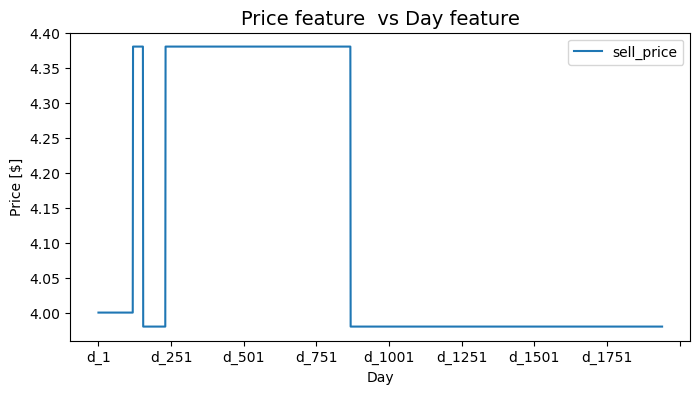

In [5]:

ax=full_data[['Day', 'sell_price']].plot(x='Day', y='sell_price', figsize=(8,4))
ax.set_title("Price feature  vs Day feature", fontsize=14)
ax.set_ylabel("Price [$]")
ax.set_xlabel("Day")


Text(0.5, 0, 'Day')

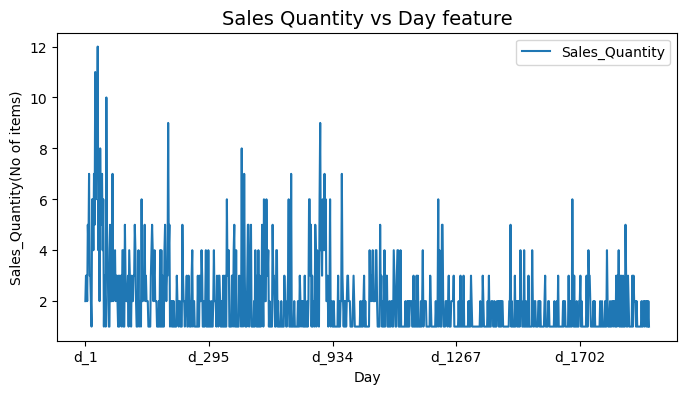

In [6]:

ax_data= full_data.loc[full_data["Sales_Quantity"]!=0, :]
ax=ax_data[['Day', 'Sales_Quantity']].plot(x='Day', y='Sales_Quantity', figsize=(8,4))
ax.set_title("Sales Quantity vs Day feature", fontsize=14)
ax.set_ylabel("Sales_Quantity(No of items)")
ax.set_xlabel("Day")


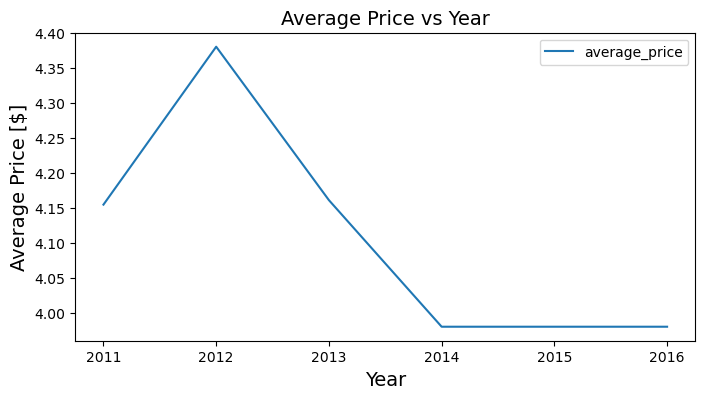

In [7]:

ax_data= full_data.groupby('year')['sell_price'].mean().reset_index(name= "average_price")
ax= ax_data[['year', 'average_price']].plot(x='year', y='average_price', figsize=(8,4))
ax.set_ylabel("Average Price [$]", fontsize=14)
ax.set_title("Average Price vs Year", fontsize=14)
ax.set_xlabel("Year", fontsize=14)
fig = ax.get_figure()
fig.savefig("average price vs year.png", dpi=300)



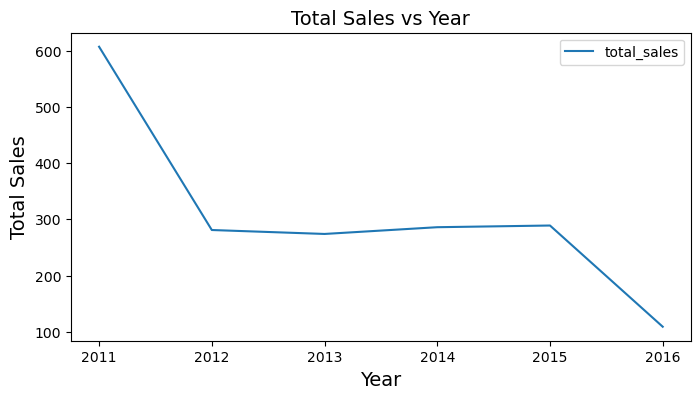

In [8]:

ax_data= full_data.groupby('year')['Sales_Quantity'].sum().reset_index(name= "total_sales")
ax=ax_data[['year', 'total_sales']].plot(x='year', y='total_sales', figsize=(8,4))
ax.set_ylabel("Total Sales", fontsize=14)
ax.set_title("Total Sales vs Year", fontsize=14)
ax.set_xlabel("Year", fontsize=14)
fig = ax.get_figure()
fig.savefig("Total Sales vs Year.png", dpi=300)


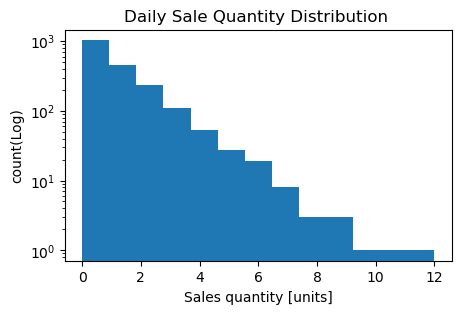

In [9]:

plt.figure(figsize=(5,3))

full_data['Sales_Quantity'].plot.hist(bins = full_data['Sales_Quantity'].nunique())  

plt.semilogy()
plt.xlabel('Sales quantity [units]')
plt.ylabel('count(Log)')
plt.title("Daily Sale Quantity Distribution ")
plt.show()

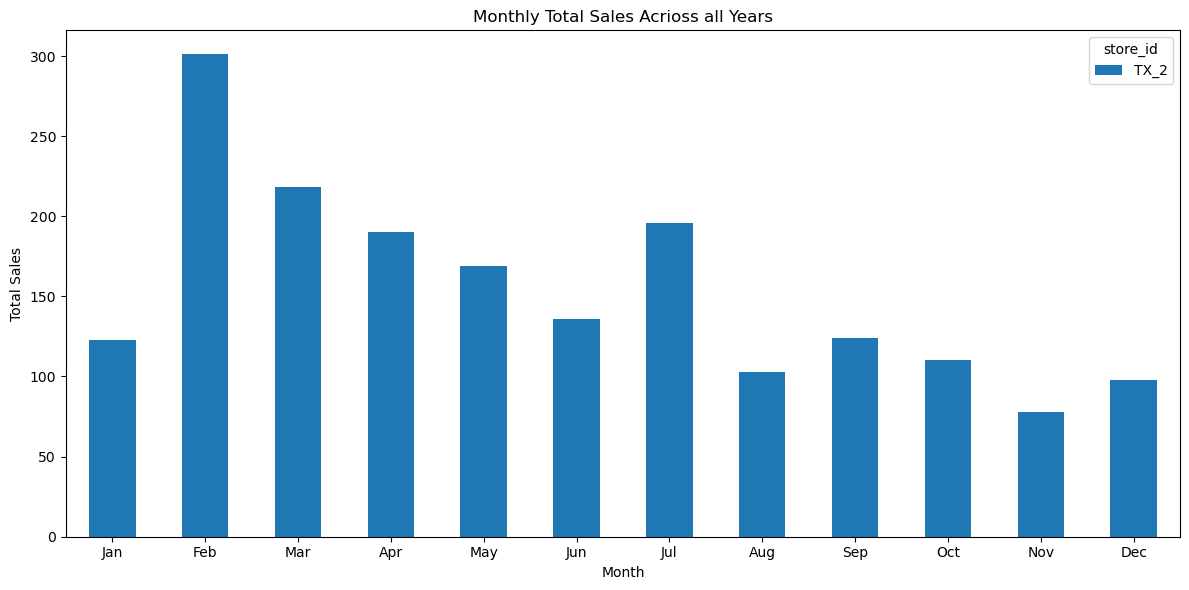

In [10]:
monthly_sales_by_store=(
    full_data.groupby(['month','store_id'])['Sales_Quantity'].sum().unstack()
)

monthly_sales_by_store.plot(kind='bar',figsize=(12,6))
plt.title('Monthly Total Sales Acrioss all Years')
plt.xlabel('Month')

plt.xticks(ticks=range(len(full_data['month'].unique())),labels=['Jan','Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],rotation=360)
plt.ylabel('Total Sales')
plt.tight_layout()
plt.legend(title='store_id')
plt.show()

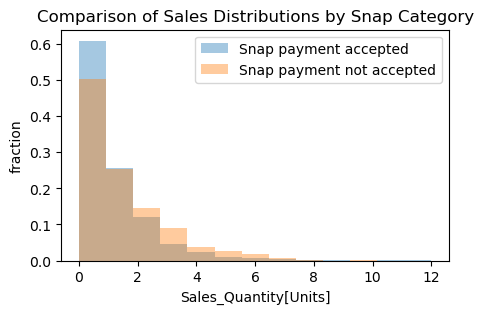

In [11]:
categories = full_data['snap_TX'].unique()
TX_data=full_data
bin_range = (TX_data['Sales_Quantity'].min(),TX_data['Sales_Quantity'].max())

plt.figure(figsize=(5,3))

labels=["Snap payment accepted", "Snap payment not accepted"]
for c, l in zip(categories, labels):
    plt.hist(TX_data[TX_data['snap_TX']==c]['Sales_Quantity'],alpha=0.4,label=l,range=bin_range,bins = TX_data['Sales_Quantity'].nunique(),density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('Sales_Quantity[Units]')
plt.title("Comparison of Sales Distributions by Snap Category")
plt.show()

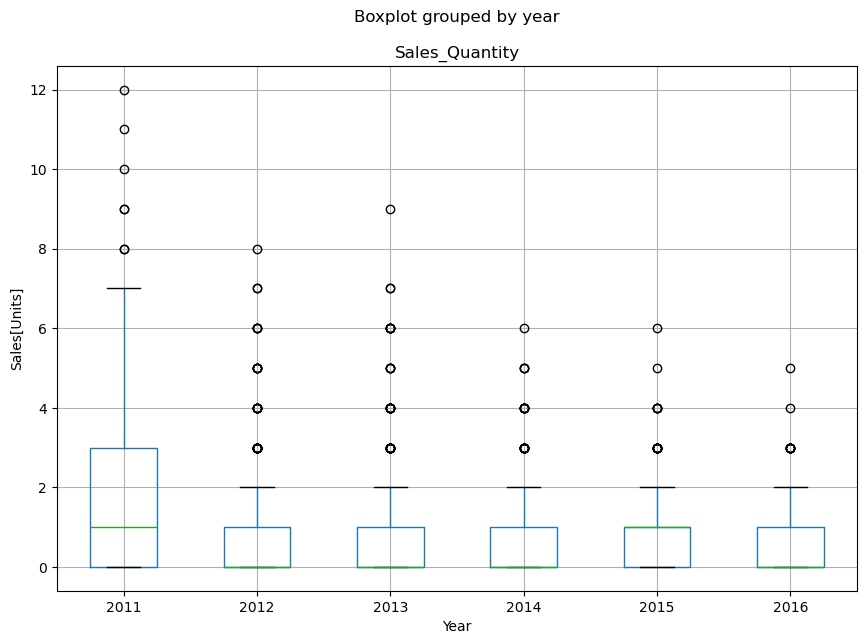

In [12]:

full_data[['Sales_Quantity','year']].boxplot(by='year',figsize=(10,7))
plt.ylabel('Sales[Units]')
plt.xlabel('Year')
plt.show()

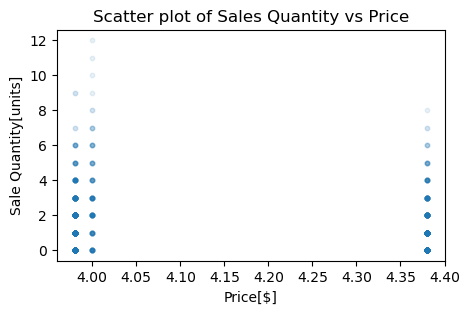

In [13]:

full_data.plot.scatter('sell_price','Sales_Quantity',figsize=(5,3),alpha=0.1,s=10)
plt.xlabel('Price[$]')
plt.ylabel('Sale Quantity[units]')
plt.title("Scatter plot of Sales Quantity vs Price")
plt.show()


In [14]:

print(full_data['sell_price'].value_counts())

sell_price
3.98    1150
4.38     672
4.00     119
Name: count, dtype: int64


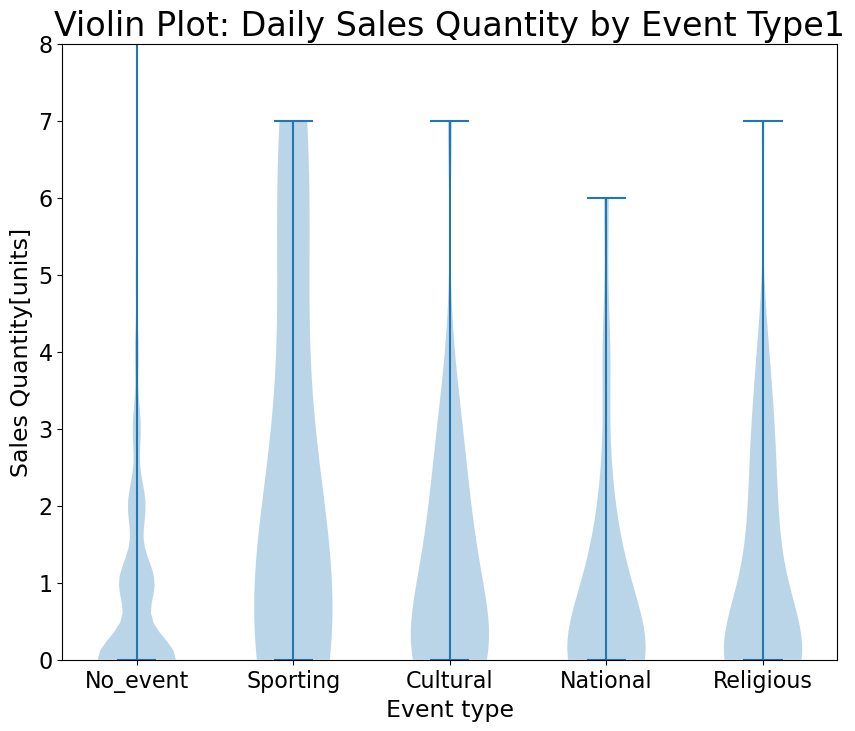

In [15]:

dataset=[]
for e_type in full_data['event_type_1'].unique():
    dataset.append(full_data[full_data['event_type_1']==e_type]['Sales_Quantity'].values)


plt.figure(figsize=(10,8))

plt.violinplot(dataset = dataset)
plt.xticks(range(1,len(dataset)+1),full_data['event_type_1'].unique())
plt.ylabel('Sales Quantity[units]',fontsize=17)
plt.xlabel('Event type',fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 8) 
plt.title('Violin Plot: Daily Sales Quantity by Event Type1',fontsize=24)
plt.savefig("Daily Sales Quantity by event type.png", dpi=300)
plt.show()


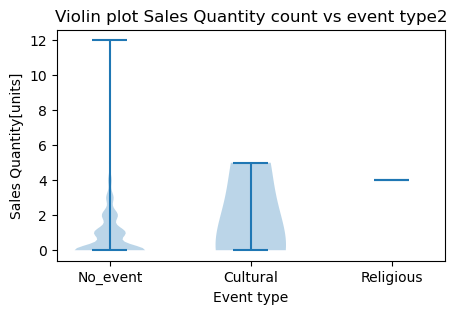

In [16]:
dataset=[]
for e_type in full_data['event_type_2'].unique():
    dataset.append(full_data[full_data['event_type_2']==e_type]['Sales_Quantity'].values)


plt.figure(figsize=(5,3))

plt.violinplot(dataset = dataset)
plt.xticks(range(1,len(dataset)+1),full_data['event_type_2'].unique())
plt.ylabel('Sales Quantity[units]')
plt.xlabel('Event type')
plt.title('Violin plot Sales Quantity count vs event type2')
plt.show()

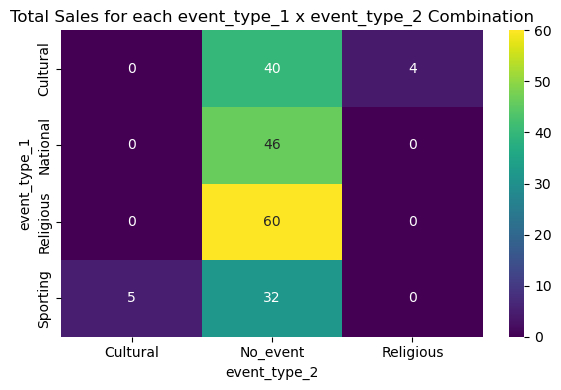

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

event_sales= full_data[['event_type_1', 'event_type_2','Sales_Quantity']]
eventcomb_sales= event_sales.groupby(['event_type_1','event_type_2'])['Sales_Quantity'].sum().reset_index(name="total_sales")
eventcomb_sales=eventcomb_sales.loc[eventcomb_sales['event_type_1']!="No_event"]
pivot= eventcomb_sales.pivot_table(
    index="event_type_1",
    columns="event_type_2",
    values="total_sales"
).fillna(0)

plt.figure(figsize=(6,4))
plt.title("Total Sales for each event_type_1 x event_type_2 Combination")
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.tight_layout()
plt.show()

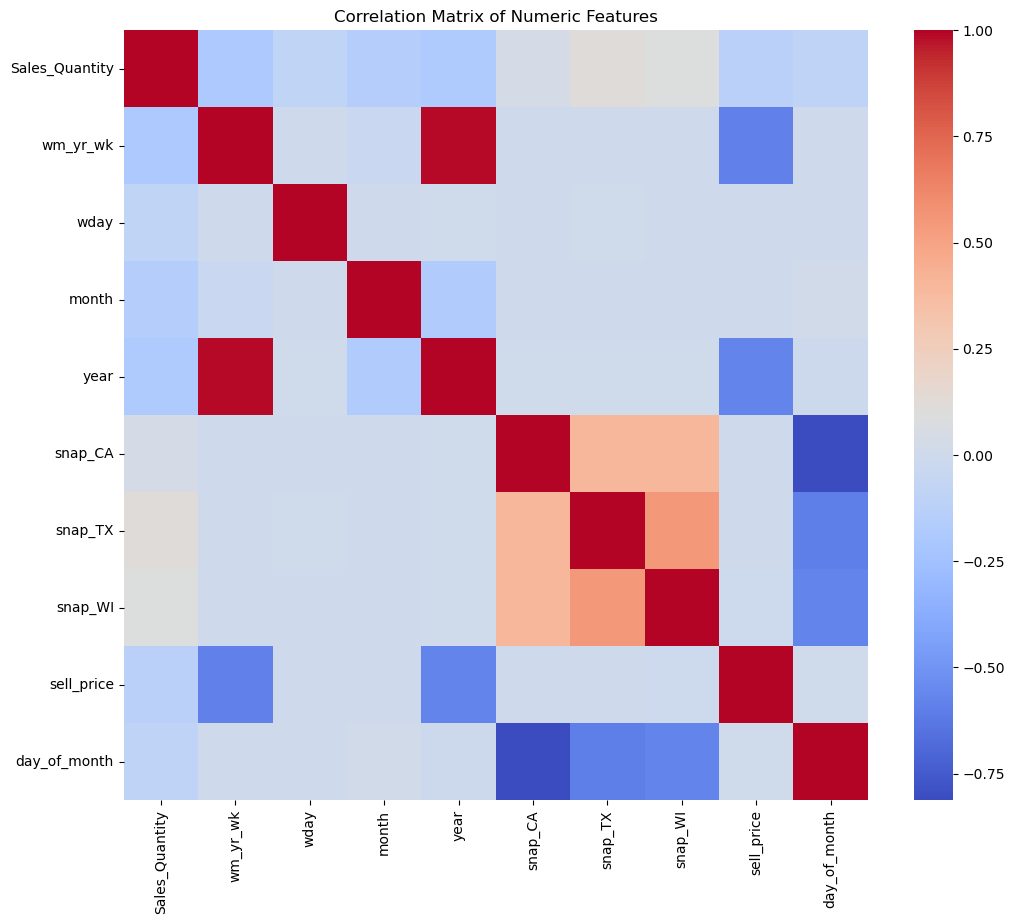

In [18]:
plt.figure(figsize=(12,10))
corr = full_data.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

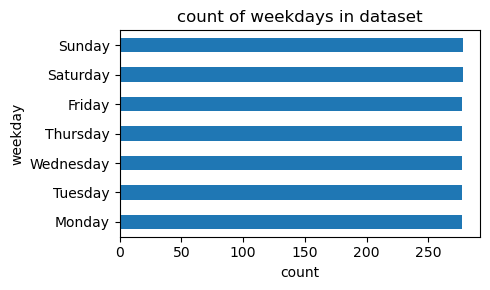

In [19]:
plt.figure(figsize=(5,3))
correct_order=['Monday','Tuesday','Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
full_data['weekday'].value_counts().reindex(correct_order).plot.barh()
plt.xlabel('count')
plt.ylabel('weekday')
plt.title('count of weekdays in dataset')
plt.tight_layout()
plt.show()

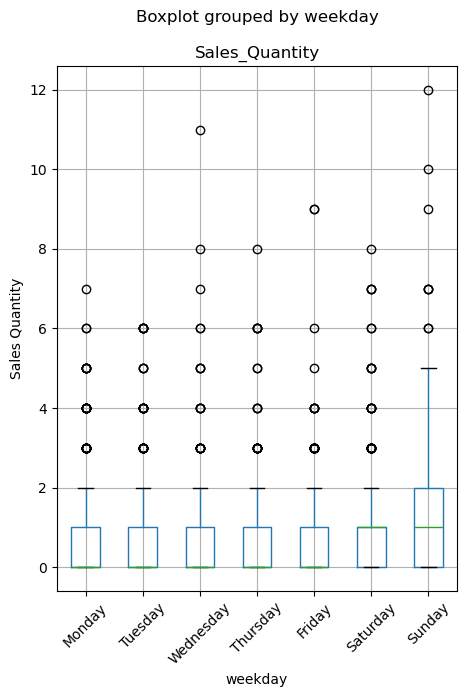

In [20]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create a temporary categorical series for plotting
weekday_cat = pd.Categorical(full_data['weekday'], categories=weekday_order, ordered=True)

full_data[['Sales_Quantity','weekday']].assign(weekday=weekday_cat).boxplot(by='weekday',figsize=(5,7))
plt.ylabel('Sales Quantity')
plt.xlabel('weekday')
plt.xticks(rotation=45)
plt.show()

In [21]:
#stores in which product was sold
print(full_data['store_id'].unique())

['TX_2']


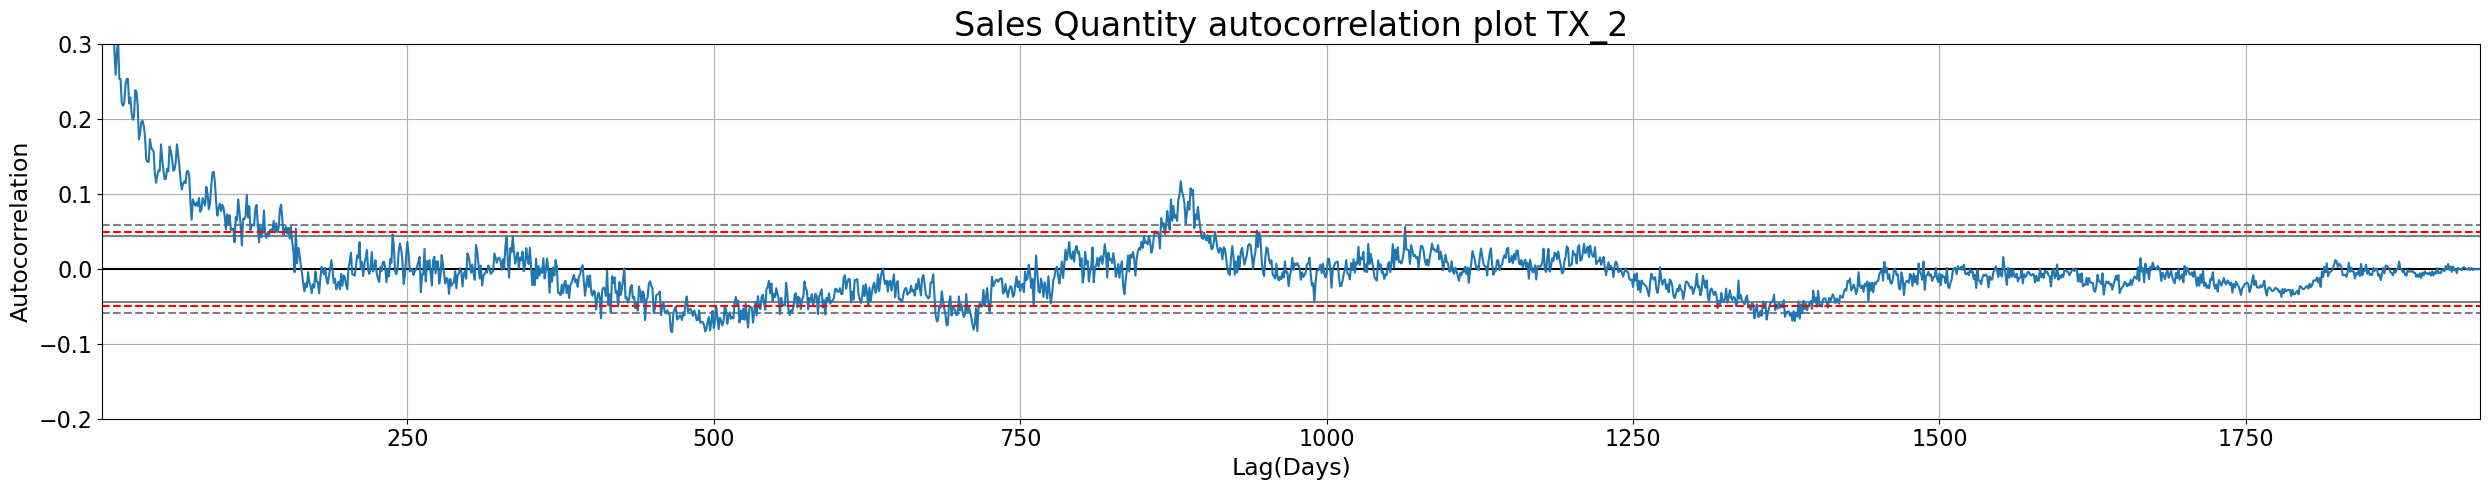

In [22]:
for store in full_data['store_id'].unique():

  mask=full_data['store_id']==store
  plt_data=full_data.loc[mask,:].sort_values(by='date')

  plt.figure(figsize=(25,5))
  autocorr_data=pd.plotting.autocorrelation_plot(plt_data['Sales_Quantity'])
  plt.axhline(y=0.05, color='red', linestyle='--')
  plt.axhline(y=-0.05, color='red', linestyle='--')
  plt.title(f"Sales Quantity autocorrelation plot {store}", fontsize=24)
  #plt.semilogy()
  plt.xlabel("Lag(Days)", fontsize=17)
  plt.ylabel("Autocorrelation", fontsize=17)
  plt.xticks(fontsize=16)
  plt.yticks(fontsize=16)
  plt.ylim(-0.2, 0.3)
    
  plt.tight_layout()
  plt.savefig("autocorrelation plot.png", dpi=300)
  plt.show()


In [23]:
# get lag where correlation enters noise region y=0.05

from statsmodels.tsa.stattools import acf

series = plt_data['Sales_Quantity']


acf_values = acf(series, nlags=250) 

for lag in range(0, 250):

    if acf_values[lag]<=0.05:
        print("the curve first enters the noise region at lag:",lag-1)
        break




the curve first enters the noise region at lag: 108


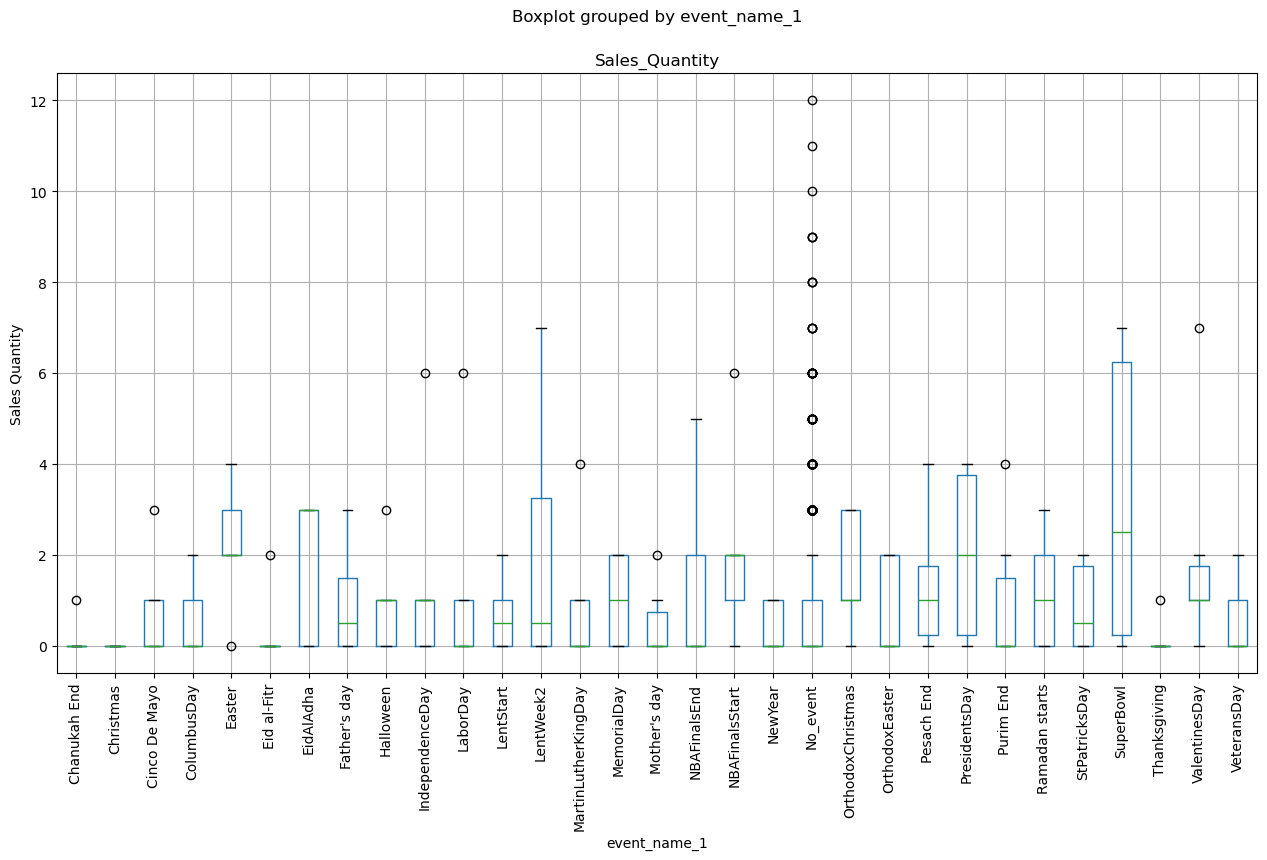

In [24]:
full_data[['Sales_Quantity','event_name_1']].boxplot(by='event_name_1',figsize=(15,8))
plt.ylabel('Sales Quantity')
plt.xlabel('event_name_1')
plt.xticks(rotation=90)
plt.show()

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from IPython.display import display
from sklearn.base import clone
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
import pickle

def make_lagged_features(df, target,p):
    """
    Create lagged features for a time-series DataFrame.

    This function generates p lagged versions of all columns in the input
    DataFrame, concatenates them with the original data, and removes rows
    containing NaN values introduced by the lagging process. The target
    column is separated as the response variable, while a selected subset
    of columns (including their lagged versions) is retained as features.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing the target variable and feature columns.
        All columns are lagged by default.
    target : str
        Name of the target column in `df`.
    p : int
        Number of lag periods to create. Must be a positive integer.

    Returns
    -------
    X : numpy.ndarray
        Feature matrix containing selected original and lagged features,
        with rows corresponding to valid (non-NaN) lagged observations.
    y : numpy.ndarray
        Target vector aligned with `X` after lagging and row removal.
    X_cols : pandas.Index
        Column names corresponding to the features in `X`.

    Notes
    -----
    - Lagged features are created using pandas `shift`.
    - Rows with NaN values resulting from lagging are dropped.
    - Only the following columns (and their lagged versions) are retained
      in the feature matrix:
      ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'month', 'wday', 'sell_price', 'day_of_month'].
    - All other original columns are excluded from `X`.

    Examples
    --------
    >>> import pandas as pd
    >>> X, y, X_cols = make_lagged_features(stock_data, target='price', p=3)
    >>> print(X.shape, y.shape)
    """
    #Input checks
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f" df must be a pandas DataFrame, not {type(df).__name__}.")

    if target not in df.columns:
        raise ValueError(f"""Target column '{target}' 
                             not found in DataFrame columns: {list(df.columns)}.""")
        
    if not isinstance(p, int) or p <= 0:
        raise ValueError(f" p must be a positive integer, not {p}.")

    if df.shape[0] <= p:
        raise ValueError(
            f"DataFrame must have more rows than p={p}. "
            f"Got {df.shape[0]} rows."
        )

    required_features = {
    'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2',
    'month', 'wday', 'sell_price', 'day_of_month'
        }

    missing = required_features - set(df.columns)
    if missing:
        raise ValueError(f"Missing required feature columns: {missing}")
        
    df_sorted= df 
    
    lagged_windows= []
    to_lag= [c for c in df_sorted.columns ]
    
    for lag in range(1,p+1):
    
        shifted = df_sorted[to_lag].shift(lag).add_suffix(f"_lag{lag}")
        lagged_windows.append(shifted) 
               
    df_lagged = pd.concat( [df_sorted[to_lag]] + lagged_windows, axis=1)  
    
    df_lagged = df_lagged.dropna().reset_index(drop=True)
    
    y= df_lagged[target].to_numpy()

    to_drop=[c for c in to_lag if c not in [ 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2','month', 'wday', 'sell_price','day_of_month']]
    X= df_lagged.drop(columns=to_drop)
    X_cols= X.columns
    
    
    return X,y, X_cols

In [26]:
def GridSearchCV_XGB_early_stopping_Regression( estimator, param_grid, cv, verbose, X, y, model, preprocessor,scoring= mean_squared_error):
   
    """
    Perform manual grid search with cross-validation for an XGBoost regressor
    using early stopping and RMSE evaluation.
    
    This function evaluates all parameter combinations in `param_grid` using
    cross-validation. For each fold, the data are preprocessed, an XGBoost
    regression model is trained with early stopping on the validation set,
    and performance is measured using the root mean squared error (RMSE).
    The parameter set achieving the lowest mean validation RMSE is selected.
    
    Parameters
    ----------
    estimator : object
        Placeholder argument (not used). Included for API consistency.
    param_grid : dict
        Dictionary with parameter names as keys and lists of parameter
        settings to try, as in sklearn's `ParameterGrid`.
    cv : sklearn.model_selection.BaseCrossValidator
        Cross-validation splitting strategy (e.g., KFold, TimeSeriesSplit).
    verbose : bool or int
        Verbosity level passed to the model's `fit` method.
    X : pandas.DataFrame
        Feature matrix.
    y : array-like
        Target vector.
    model : xgboost.XGBRegressor
        XGBoost regressor instance to be trained and tuned.
    preprocessor : sklearn transformer
        Preprocessing transformer applied to the features before model fitting.
    scoring : callable, default=mean_squared_error
        Scoring function used to evaluate predictions. Must be
        `sklearn.metrics.mean_squared_error`; RMSE is computed internally.

    Returns
    -------
    best_parameter : dict
        Parameter set from `param_grid` that yields the lowest mean
        validation RMSE across folds.
    corr_train_score : float
        Mean training RMSE corresponding to the best parameter set.

    Raises
    ------
    ValueError
        If `scoring` is not `mean_squared_error`.

    Notes
    -----
    - Early stopping is applied with `early_stopping_rounds=50` using the
      validation fold as the evaluation set.
    - RMSE is computed as the square root of the mean squared error.
    - This function does not refit the model on the full dataset after
      selecting the best parameters.

    Examples
    --------
    >>> best_params, train_rmse = GridSearchCV_XGB_early_stopping_Regression(
          estimator=None,
          param_grid=param_grid,
          cv=tscv,
          verbose=False,
          X=X,
          y=y,
          model=xgb_model,
          preprocessor=preprocessor
      )
    """
    if scoring!= mean_squared_error:
        raise ValueError(" This function was made for regression with sqrt mean squared error for scoring. consider modifying the function")

    if not isinstance(param_grid, dict) or len(param_grid) == 0:
        raise TypeError("param_grid must be a non-empty dictionary.")

    if not hasattr(cv, "split"):
        raise TypeError("cv must be a valid cross-validation splitter with a split() method.")

    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame (this function uses .iloc indexing).")

    if X.shape[0] != len(y):
        raise ValueError("X and y must have the same number of rows.")

    if not hasattr(preprocessor, "fit") or not hasattr(preprocessor, "transform"):
        raise TypeError("preprocessor must implement fit() and transform().")
  
    mean_val_scores=np.zeros(len(ParameterGrid(param_grid)))
    mean_train_scores=np.zeros(len(ParameterGrid(param_grid)))
    prep = Pipeline(steps=[('preprocessor', preprocessor)])
                              
    for p in range(len(ParameterGrid(param_grid))):
            params= ParameterGrid(param_grid)[p]

            splits_train_sc= np.zeros(len(list(cv.split(X))))
            splits_val_sc= np.zeros(len(list(cv.split(X))))

    
            for sp, (train_index, val_index) in enumerate(cv.split(X)):
                  X_train= X.iloc[train_index]
                  y_train= y[train_index]
                  X_val= X.iloc[val_index]
                  y_val= y[val_index]

                  this_prep = clone(prep)
                  this_model= clone(model)
                  
                  
                  X_train_t= this_prep.fit_transform(X_train)
                  X_val_t   = this_prep.transform(X_val)
                
                  this_model.set_params(**params,early_stopping_rounds=50)
                  
                  this_model.fit(X_train_t, y_train, eval_set=[(X_val_t, y_val)], verbose= verbose)
        
                  y_train_pred= this_model.predict(X_train_t)
                  y_val_pred= this_model.predict(X_val_t)

                  splits_train_sc[sp]=  np.sqrt(scoring(y_train, y_train_pred))
                  splits_val_sc[sp]=   np.sqrt(scoring(y_val, y_val_pred))

                  
             
             
            mean_train_scores[p]= splits_train_sc.mean()
        
            mean_val_scores[p]= splits_val_sc.mean()
        
    best_parameter= ParameterGrid(param_grid)[np.argmin(mean_val_scores)]
    best_val_score= mean_val_scores.min()
    corr_train_score= mean_train_scores[np.argmin(mean_val_scores)]

        
    return best_parameter, corr_train_score

In [27]:


def MLpipe_TimeSeriesSplit_RMSE(X, y, preprocessor, ML_algo, param_grid, XGBoost= False, tiseries_n_splits=None):
    """
    Run a time-series machine learning pipeline with preprocessing,
    hyperparameter tuning, and RMSE evaluation.

    This function performs a single chronological train/test split
    (80% / 20%, without shuffling), followed by hyperparameter tuning
    on the training portion using TimeSeriesSplit cross-validation.
    Model performance is evaluated on the held-out test set using
    root mean squared error (RMSE).

    Two workflows are supported:
    - Standard sklearn models using GridSearchCV.
    - XGBoost regression using a custom grid search with early stopping.

    Parameters
    ----------
    X : pandas.DataFrame or numpy.ndarray
        Feature matrix ordered in time. Must have the same number of rows as `y`.
    y : pandas.Series or numpy.ndarray
        Target vector ordered in time.
    preprocessor : sklearn.compose.ColumnTransformer
        Preprocessing transformer applied before model fitting.
    ML_algo : sklearn estimator
        Machine learning estimator used in the pipeline (e.g., Lasso, Ridge,
        ElasticNet, XGBRegressor).
    param_grid : dict
        Dictionary defining the hyperparameter search space.
    XGBoost : bool, default=False
        If True, uses a custom grid search with early stopping for XGBoost.
        If False, uses sklearn's GridSearchCV.
    tiseries_n_splits : int, optional
        Number of splits for TimeSeriesSplit cross-validation.

    Returns
    -------
    test_score : float
        RMSE of the best model evaluated on the test set.
    best_model : sklearn estimator
        Best fitted model obtained after hyperparameter tuning.

    Raises
    ------
    ValueError
        If the number of rows in X and y do not match, or if preprocessing
        causes row loss.
    TypeError
        If `param_grid` is not a dictionary or if `XGBoost` is not a boolean.

    Notes
    -----
    - The train/test split is chronological (shuffle=False).
    - Hyperparameter selection minimizes RMSE.
    - For non-XGBoost models, GridSearchCV uses
      `neg_root_mean_squared_error` as the scoring metric.
    - For XGBoost models, early stopping is applied during cross-validation
      and disabled when refitting on the full training set.
    - This function fits and returns a single best model (not multiple runs).

    Examples
    --------
    >>> test_rmse, model = MLpipe_TimeSeriesSplit_RMSE(
    ...     X=X,
    ...     y=y,
    ...     preprocessor=preprocessor,
    ...     ML_algo=model,
    ...     param_grid=param_grid,
    ...     XGBoost=False,
    ...     tiseries_n_splits=4
    ... )
    """
    if not isinstance(X, (pd.DataFrame, np.ndarray)):
        raise TypeError("X must be a pandas DataFrame or a NumPy array.")

    if not isinstance(y, (pd.Series, np.ndarray)):
        raise TypeError("y must be a pandas Series or a NumPy array.")

    if not hasattr(preprocessor, "fit") or not hasattr(preprocessor, "transform"):
        raise TypeError("preprocessor must implement fit() and transform().")

    if not hasattr(ML_algo, "fit") or not hasattr(ML_algo, "predict"):
        raise TypeError("ML_algo must implement fit() and predict().")

    if not isinstance(tiseries_n_splits, int) or tiseries_n_splits < 2:
        raise ValueError("tiseries_n_splits must be an integer >= 2.")

    if X.shape[0] != y.shape[0]:
        raise ValueError("row mismatch between inputs X matrix and y matrix")
        
    if not isinstance(param_grid, dict):
        raise TypeError("param_grid should be a dictionary")
        
    if not isinstance(XGBoost, bool):
        raise TypeError("XGBoost should be a Boolean Value specifying if the model is XGBoost")

   
    test_score = None
    best_model = None
    best_params=[]
    nr_states= list(range(10))
    
        
    X_other, X_test, y_other, y_test= train_test_split(X, y, 
                                    test_size=0.2, shuffle=False)

        
        
    tscv = TimeSeriesSplit(n_splits= tiseries_n_splits)

        
    pipe = Pipeline([
                  ("preprocess", preprocessor),
                       ("model", ML_algo)
                    ])
 
    grid= GridSearchCV(pipe, param_grid= param_grid, 
                           scoring= 'neg_root_mean_squared_error',
                           cv=tscv, return_train_score = False, verbose=True)

    if XGBoost:
            
           best_parameters, _= GridSearchCV_XGB_early_stopping_Regression( estimator=ML_algo, param_grid= param_grid, 
                                                                    cv= tscv, verbose=False, X=X_other, y=y_other, model= ML_algo, preprocessor=preprocessor,scoring= mean_squared_error)
                                                                                     
           best_parameters_prefixed = {f"model__{k}": v for k, v in best_parameters.items()}
           best_pipe= pipe.set_params(**best_parameters_prefixed, model__early_stopping_rounds=None)
           best_pipe.fit(X_other, y_other)
            
           fitted_preprocessor = best_pipe.named_steps['preprocess']
           X_other_transformed= fitted_preprocessor.transform(X_other)
        
           if  X_other_transformed.shape[0] != X_other.shape[0]:
               raise ValueError("rows lost after preprocessing X_other")

           best_model= best_pipe.named_steps['model']
        
           y_test_pred = best_pipe.predict(X_test)
           best_params.append(best_parameters)
           test_score= np.sqrt(mean_squared_error(y_test, y_test_pred))
            
    else:
           grid.fit(X_other, y_other)
           print("___________GridSearchCV Complete!! Printing results ____________")
           display(pd.DataFrame(grid.cv_results_))

        
           fitted_preprocessor = grid.best_estimator_.named_steps['preprocess']
           X_other_transformed= fitted_preprocessor.transform(X_other)

        
        
           if  X_other_transformed.shape[0] != X_other.shape[0]:
               raise ValueError("rows lost after preprocessing X_other")
       

           print("\nX_other before transformation:")
           display(X_other.head())


        
           print("\nX_other after transformation:")
           display(pd.DataFrame(X_other_transformed))
        

           best_model= grid.best_estimator_
        
           y_test_pred= best_model.predict(X_test)


           X_test_transformed= fitted_preprocessor.transform(X_test)
        
           if  X_test_transformed.shape[0] != X_test.shape[0]:
                raise ValueError("rows lost after preprocessing X_test")


           print("\nX_test before transformation:")
           display(X_test.head(15))

           print("\nX_test after transformation:")
           display(pd.DataFrame(X_test_transformed).head(15))

           best_params.append(grid.best_params_)
            
           test_score= np.sqrt(mean_squared_error(y_test, y_test_pred))
        
    
    return test_score, best_model


In [28]:
class CyclicalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, max_value):
        self.max_value = max_value

    def fit(self, X, y=None):

        if hasattr( X, "columns"):
            self.feature_names_in_= list(X.columns)
        else:
            self.feature_names_in_= [f"x{i}" for i in range(X.shape[1])]

        self.feature_names_out_= []
        for f in self.feature_names_in_:
            self.feature_names_out_.extend([f"{f}_sin", f"{f}_cos"])
        
        return self

    def transform(self, X):
        X = np.asarray(X)
        sin_x = np.sin(2 * np.pi * X / self.max_value)
        cos_x = np.cos(2 * np.pi * X / self.max_value)

        return np.c_[sin_x, cos_x]

    def get_feature_names_out(self, input_features= None):

        return np.array(self.feature_names_out_)

In [29]:

def preprocessor_builder( lags=None, cat_ftrs= None, ordinal_ftrs= None, ordinal_cats=None, target_ftr_tolag=None, month_ftrs=None, wday_ftrs= None): 

    """
    Build a ColumnTransformer for lagged time-series features with mixed
    categorical, ordinal, cyclical, and numerical preprocessing.

    This function constructs a preprocessing pipeline that:
    - Expands input feature groups into their lagged versions,
    - Applies appropriate encodings per feature type,
    - Handles cyclical time features (month and weekday),
    - Standardizes all resulting features for downstream modeling.

    All required inputs must be explicitly provided; passing `None` for any
    argument raises an error.

    Parameters
    ----------
    lags : int
        Number of lag periods used to construct lagged feature names.
    cat_ftrs : list of str
        Names of categorical features to be one-hot encoded after lagging.
    ordinal_ftrs : list of str
        Names of ordinal features to be ordinal-encoded after lagging.
    ordinal_cats : list of list
        Category orderings for ordinal features. The first element is reused
        for all ordinal lagged features.
    target_ftr_tolag : list of str
        Names of numerical target-related features to be lagged and
        standardized.
    month_ftrs : list of str
        Feature names representing month-based time features to be encoded
        cyclically (period = 12).
    wday_ftrs : list of str
        Feature names representing weekday-based time features to be encoded
        cyclically (period = 7).

    Returns
    -------
    my_preprocessor : sklearn.compose.ColumnTransformer
        A ColumnTransformer that applies:
        - Cyclical encoding + scaling to month and weekday features,
        - One-hot encoding + scaling to categorical features,
        - Ordinal encoding + scaling to ordinal features,
        - Standard scaling to numerical lagged features.

    Raises
    ------
    ValueError
        If any required input argument is None.

    Notes
    -----
    - All feature lists are expanded to include lagged versions
      (e.g., `feature_lag1`, ..., `feature_lag{lags}`).
    - The original `month` and `wday` features are included in addition to
      their lagged versions.
    - Event-related categorical features
      (`event_name_1`, `event_type_1`, `event_name_2`, `event_type_2`)
      are always included in the one-hot encoding step.
    - Ordinal category orderings are duplicated to match the number of
      ordinal lagged features.
    - All transformed features are scaled using `StandardScaler`.

    Examples
    --------
    >>> preprocessor = preprocessor_builder(
    ...     lags=3,
    ...     cat_ftrs=['event_name_1', 'event_type_1'],
    ...     ordinal_ftrs=['snap_CA'],
    ...     ordinal_cats=[['No', 'Yes']],
    ...     target_ftr_tolag=['sales'],
    ...     month_ftrs=['month'],
    ...     wday_ftrs=['wday']
    ... )
    """ 
    if not isinstance(lags, int) or lags <= 0:
            raise ValueError(f"`lags` must be a positive integer, got {lags}.")

    for name, ftrs in {
            "cat_ftrs": cat_ftrs,
            "ordinal_ftrs": ordinal_ftrs,
            "target_ftr_tolag": target_ftr_tolag,
            "month_ftrs": month_ftrs,
            "wday_ftrs": wday_ftrs,
            }.items():
          
            if not isinstance(ftrs, list) or not all(isinstance(f, str) for f in ftrs):
                raise TypeError(f"`{name}` must be a list of strings.")
    if len(set(ordinal_cats[0])) != len(ordinal_cats[0]):
            raise ValueError("Ordinal categories must be unique.")

    all_features = (
                cat_ftrs
                + ordinal_ftrs
                + target_ftr_tolag
                + month_ftrs
                + wday_ftrs
            )

    if len(all_features) != len(set(all_features)):
             raise ValueError("Feature names must be unique across all feature groups.")

            
    if any(v is None for v in [
            lags, cat_ftrs, ordinal_ftrs, ordinal_cats,
            target_ftr_tolag, month_ftrs, wday_ftrs ]):
                 raise ValueError("One or more required inputs to preprocessor_builder() are None.")

    
    onehot_ftrs=[]
    ordenc_ftrs=[]
    standsc_ftrs=[]
    c1_ftrs=[]
    c2_ftrs=[]

    for ftr in cat_ftrs:
       for lag in range(1,lags+1):
            onehot_ftrs.append(ftr+ f"_lag{lag}")

    for ftr in ordinal_ftrs:
        for lag in range(1, lags+1):
            ordenc_ftrs.append(ftr+ f"_lag{lag}")

    for ftr in target_ftr_tolag:
        for lag in range(1,lags+1):
            standsc_ftrs.append(ftr+ f"_lag{lag}")

    for ftr in month_ftrs:
        for lag in range(1,lags+1):
            c1_ftrs.append(ftr+ f"_lag{lag}")
    c1_ftrs.append('month')

    for ftr in wday_ftrs:
        for lag in range(1,lags+1):
            c2_ftrs.append(ftr+ f"_lag{lag}")
    c2_ftrs.append('wday')

        
    onehot_ftrs.extend(['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2'])
    ordenc_ftrs.append('sell_price')
    ordinal_cats= [sorted(ordinal_cats[0]).copy() for _ in range(len(ordenc_ftrs))]


    my_preprocessor = ColumnTransformer(
            transformers=[
                ('month_enc', Pipeline([
                          ('cyc1',CyclicalEncoder(max_value=12)),
                           ('scale1', StandardScaler())
                ]), c1_ftrs),
                ('wday_enc',  Pipeline([
                          ('cyc2', CyclicalEncoder(max_value=7)),
                          ('scale2', StandardScaler())
                
                ]),c2_ftrs),
                ('onehot',  Pipeline([ 
                                     ('oh',OneHotEncoder(sparse_output=False,handle_unknown='ignore')),
                                       ('scale3', StandardScaler())
                                     ]), onehot_ftrs),
                ('ord', Pipeline([('orde', OrdinalEncoder(categories= ordinal_cats)),
                                  ('scale4', StandardScaler())
                                 ]), ordenc_ftrs),
                ('standsc', StandardScaler(), standsc_ftrs)
            
            ])

    return my_preprocessor

In [29]:


results_dict={}

full_data = full_data.sort_values(by=['state_id','date']).reset_index(drop=True)


param_grid_list=[{
    'model__alpha': np.logspace(-3, 3, 7),
    'model__max_iter': [10000]
},
            {
    'model__alpha': np.logspace(-3, 3, 7),
    'model__solver': ['saga'],
    'model__max_iter': [10000]
},

            {
    'model__max_depth': list(range(2, 20)),
    'model__random_state': [42, 84, 126, 168]
},
{  
    
     'n_estimators': [10000],
    'alpha': [0e0, 1e-2, 1e-1, 1e0, 1e1, 1e2],
    'lambda': [0e0, 1e-2, 1e-1, 1e0, 1e1, 1e2],
     'max_depth': [1,3,10,30],
      'seed': [0],
     'learning_rate': [0.03],
     'subsample' : [0.66],
     'colsample_bytree': [0.5],
      'missing': [np.nan]

} 
                
           ]

r_state= 45
split_n_splits=5

ML_algo=[Lasso(fit_intercept=True, random_state=r_state),
         Ridge(fit_intercept=True, random_state=r_state),
        
         RandomForestRegressor(random_state=r_state),
         
         xgb.XGBRegressor(random_state=r_state)]

result_scores=[]
best_models=[]
optimum_lags=[]

    
for i, (algo, param_grid) in enumerate(zip( ML_algo, param_grid_list)):
    
    lag_stop_flag=False
    lagger=1
    ding=0
    lags_testscores= []
    lags_models= []
    Best_lag_test_sc=[]
    
    



    while lag_stop_flag== False:
        
        if i!=3:
             lagger=min(lagger*2, int(0.8*full_data.shape[0]))
        else:
            lagger = 16
            
    
            
        X, y, X_cols= make_lagged_features(full_data.drop(columns=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'Day','date', 'wm_yr_wk', 'weekday', 'd']), target= 'Sales_Quantity',p=lagger)

        cat_ftrs= ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

        ordinal_ftrs=['sell_price']
        ordinal_cats=[[4.38, 4.0, 3.98]]
        other_ftrs=['Sales_Quantity', 'day_of_month', 'year']
        month_ftrs=['month']
        wday_ftrs=['wday']

        preprocessor= preprocessor_builder( lags=lagger, cat_ftrs= cat_ftrs, ordinal_ftrs= ordinal_ftrs, ordinal_cats=ordinal_cats, 
                                            target_ftr_tolag=other_ftrs, month_ftrs=month_ftrs, wday_ftrs= wday_ftrs)



        model_names= ['Linear regression; L1 reg',
                     'Linear regression; L2 reg',
                      'Random Forest',
                    'XGBoost']

        
    
        
        
        print(f"\n\n-----------//////////// ALGORITHM : {model_names[i]} ////////////----------\n\n")
    
        if model_names[i] == "XGBoost":
            #no worries, algorith is reinitialized for every lag
            test_score, best_model = MLpipe_TimeSeriesSplit_RMSE(X, y, 
                                preprocessor= preprocessor, ML_algo= algo, param_grid= param_grid, XGBoost=True, tiseries_n_splits= split_n_splits)
        else:    
              test_score, best_model = MLpipe_TimeSeriesSplit_RMSE(X, y, 
                                preprocessor= preprocessor, ML_algo= algo, param_grid= param_grid, tiseries_n_splits= split_n_splits)
        

        # custom early stop code
        last_value = lags_testscores[-1] if lags_testscores else 0
        
        if min(last_value, test_score)==last_value:
            if lags_testscores:
               ding+=1
        else:
            if (abs(last_value- test_score)/test_score)<=0.005:
                ding+=1
            else:
                ding=0
        print(f"current mean test_score: {test_score}, lag: {lagger}")

        #stopping xgboost at lag=16 for computational reasons
        if i==3:
             ding=10
        

        # 4 tries for monitoring
        if ding>=4 or lagger==int(0.8*full_data.shape[0]):
            lag_stop_flag=True
            
            
        lags_testscores.append(test_score)
        lags_models.append(best_model)
        
        

    # want the minumum error score
    Best_lag_test_sc= min(lags_testscores)
    best_models.append(lags_models[np.argmin(np.array(lags_testscores))])
    optimum_lags.append(2**(1+ np.argmin(np.array(lags_testscores))))

    result_scores.append(Best_lag_test_sc)
        
    print(f"best test score: {Best_lag_test_sc}")  
    print(f"optimum number of lags: {optimum_lags[-1]}")


    

    
Results=pd.DataFrame({
                       'models':['Linear regression; L1 reg',
                                'Linear regression; L2 reg',
                                'Random Forest',
                                'XGBoost'],
                      'mean test score(sqrt(mean_squared_error))':np.round(result_scores,3),
                        })
                     
display(Results)
Results.to_excel("Test Score Results(RMSE).xlsx", index=False)





-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.126881,0.026399,0.015266,0.002573,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-1.854939,-1.014717,-1.916068,-1.383082,-0.906258,-1.415013,0.415856,7
1,0.074946,0.031488,0.020475,0.003622,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-1.813902,-0.938062,-1.857802,-1.315953,-0.878210,-1.360786,0.416155,2
2,0.032070,0.003403,0.014358,0.002032,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.650202,-0.855467,-1.620279,-1.238204,-0.861352,-1.245101,0.347560,1
3,0.030400,0.004628,0.016066,0.003000,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.596526,-1.701349,-1.574870,-1.204225,-0.993065,-1.414007,0.269428,3
4,0.029187,0.007533,0.015483,0.004101,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.600018,-1.701349,-1.574870,-1.204225,-0.993065,-1.414705,0.269904,4
5,0.029755,0.006954,0.016432,0.002928,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.600018,-1.701349,-1.574870,-1.204225,-0.993065,-1.414705,0.269904,4
6,0.034158,0.006388,0.017930,0.001999,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.600018,-1.701349,-1.574870,-1.204225,-0.993065,-1.414705,0.269904,4



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag2,event_name_1_lag2,event_type_1_lag2,event_name_2_lag2,event_type_2_lag2,snap_CA_lag2,snap_TX_lag2,snap_WI_lag2,sell_price_lag2,day_of_month_lag2
0,3,1,No_event,No_event,No_event,No_event,4.0,31,3.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,4,2,No_event,No_event,No_event,No_event,4.0,1,0.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,5,2,No_event,No_event,No_event,No_event,4.0,2,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,6,2,No_event,No_event,No_event,No_event,4.0,3,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,7,2,No_event,No_event,No_event,No_event,4.0,4,5.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,0.630045,0.630557,0.629533,1.247831,1.246146,1.249519,1.378510,1.104120,0.615231,-0.312700,...,-0.0254,0.059805,0.059151,0.060458,1.313116,0.657611,1.623830,1.510130,-1.374053,-1.372629
1,0.630045,0.630557,1.139534,1.247831,1.246146,0.722626,0.613495,1.377211,-0.612028,-1.272344,...,-0.0254,0.059805,0.059151,0.060458,-0.650860,1.312268,1.737529,1.623830,-1.374053,-1.372629
2,1.140194,0.630557,1.139534,0.721115,1.246146,0.722626,-0.613495,0.612028,-1.377211,-1.272344,...,-0.0254,0.059805,0.059151,0.060458,1.313116,-0.651702,-1.673459,1.737529,-1.374053,-1.372629
3,1.140194,1.140856,1.139534,0.721115,0.719606,0.722626,-1.378510,-0.615231,-1.104120,-0.312700,...,-0.0254,0.059805,0.059151,0.060458,0.658457,1.312268,-1.559759,-1.673459,-1.374053,-1.372629
4,1.140194,1.140856,1.139534,0.721115,0.719606,0.722626,-1.105479,-1.380415,0.001602,0.883957,...,-0.0254,0.059805,0.059151,0.060458,2.622432,0.657611,-1.446060,-1.559759,-1.374053,-1.372629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,1.105479,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,1.055332,0.941632,1.822282,1.825190
1547,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,1.378510,1.104120,0.615231,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,-0.651702,1.169031,1.055332,1.822282,1.825190
1548,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,0.613495,1.377211,-0.612028,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,0.658457,-0.651702,1.282731,1.169031,1.822282,1.825190
1549,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,-0.613495,0.612028,-1.377211,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.657611,1.396430,1.282731,1.822282,1.825190



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag2,event_name_1_lag2,event_type_1_lag2,event_name_2_lag2,event_type_2_lag2,snap_CA_lag2,snap_TX_lag2,snap_WI_lag2,sell_price_lag2,day_of_month_lag2
1551,7,5,No_event,No_event,No_event,No_event,3.98,1,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0
1556,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,4.0
1557,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,Cinco De Mayo,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1558,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0
1559,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,7.0
1560,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,8.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,1.140194,1.140856,0.629533,-0.717901,-0.718927,-1.243769,-1.105479e+00,-1.380415,0.001602,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,-0.651702,1.623830,1.510130,1.822282,1.82519
1,0.630045,1.140856,0.629533,-1.244617,-0.718927,-1.243769,-2.990541e-16,-1.107324,1.107324,1.416519,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-1.673459,1.623830,1.822282,1.82519
2,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.105479e+00,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-1.559759,-1.673459,1.822282,1.82519
3,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.378510e+00,1.104120,0.615231,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,-1.446060,-1.559759,1.822282,1.82519
4,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,6.134945e-01,1.377211,-0.612028,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,-0.651702,-1.332360,-1.446060,1.822282,1.82519
5,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-6.134945e-01,0.612028,-1.377211,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,1.313116,-0.651702,-1.218660,-1.332360,1.822282,1.82519
6,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-1.378510e+00,-0.615231,-1.104120,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,1.312268,-1.104961,-1.218660,1.822282,1.82519
7,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-1.105479e+00,-1.380415,0.001602,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-0.991261,-1.104961,1.822282,1.82519
8,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-2.990541e-16,-1.107324,1.107324,1.416519,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-0.877562,-0.991261,1.822282,1.82519
9,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.105479e+00,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,-0.763862,-0.877562,1.822282,1.82519


current mean test_score: 0.9964590382197392, lag: 2


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.310744,0.090500,0.023032,0.004871,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-1.889543,-1.134310,-1.723687,-1.483188,-0.931344,-1.432414,0.356741,7
1,0.101709,0.041277,0.024781,0.004452,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-1.834957,-1.037280,-1.658487,-1.369863,-0.875526,-1.355223,0.361531,2
2,0.051119,0.010257,0.022606,0.003676,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.623403,-0.805945,-1.472106,-1.221152,-0.846777,-1.193876,0.326686,1
3,0.046441,0.007962,0.019523,0.004438,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.595870,-1.702128,-1.574729,-1.204230,-0.992725,-1.413937,0.269594,3
4,0.049412,0.012670,0.021613,0.004405,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.601109,-1.702128,-1.574729,-1.204230,-0.992725,-1.414984,0.270308,4
5,0.045103,0.010441,0.022240,0.003772,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.601109,-1.702128,-1.574729,-1.204230,-0.992725,-1.414984,0.270308,4
6,0.046132,0.005446,0.023105,0.003261,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.601109,-1.702128,-1.574729,-1.204230,-0.992725,-1.414984,0.270308,4



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag4,event_name_1_lag4,event_type_1_lag4,event_name_2_lag4,event_type_2_lag4,snap_CA_lag4,snap_TX_lag4,snap_WI_lag4,sell_price_lag4,day_of_month_lag4
0,5,2,No_event,No_event,No_event,No_event,4.0,2,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,6,2,No_event,No_event,No_event,No_event,4.0,3,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,7,2,No_event,No_event,No_event,No_event,4.0,4,5.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,1,2,No_event,No_event,No_event,No_event,4.0,5,0.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,2,2,SuperBowl,Sporting,No_event,No_event,4.0,6,4.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,280
0,1.140564,0.631126,0.631640,0.632154,1.140564,0.722987,1.248203,1.246515,1.244830,0.723919,...,1.311788,0.657372,-1.673268,1.741196,1.626881,1.512641,-1.376619,-1.375189,-1.373764,-1.372344
1,1.140564,1.141226,0.631640,0.632154,1.140564,0.722987,0.721474,1.246515,1.244830,0.723919,...,-0.651458,1.311788,-1.559434,-1.673015,1.740662,1.626400,-1.376619,-1.375189,-1.373764,-1.372344
2,1.140564,1.141226,1.141889,0.632154,1.140564,0.722987,0.721474,0.719963,1.244830,0.723919,...,1.311788,-0.651458,-1.445600,-1.559208,-1.672790,1.740158,-1.376619,-1.375189,-1.373764,-1.372344
3,1.140564,1.141226,1.141889,1.142552,1.140564,0.722987,0.721474,0.719963,0.718454,0.723919,...,0.657372,1.311788,-1.331766,-1.445401,-1.559008,-1.672593,-1.376619,-1.375189,-1.373764,-1.372344
4,1.140564,1.141226,1.141889,1.142552,1.140564,0.722987,0.721474,0.719963,0.718454,0.723919,...,2.620618,0.657372,-1.217931,-1.331594,-1.445227,-1.558835,-1.376619,-1.375189,-1.373764,-1.372344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,0.002957,-0.651458,1.058754,0.944547,0.830408,0.716333,1.821555,1.824462,1.827380,1.830308
1545,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,0.002957,0.002957,1.172589,1.058354,0.944190,0.830091,1.821555,1.824462,1.827380,1.830308
1546,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,-0.651458,0.002957,1.286423,1.172161,1.057972,0.943849,1.821555,1.824462,1.827380,1.830308
1547,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,-0.651458,-0.651458,1.400257,1.285968,1.171754,1.057608,1.821555,1.824462,1.827380,1.830308



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag4,event_name_1_lag4,event_type_1_lag4,event_name_2_lag4,event_type_2_lag4,snap_CA_lag4,snap_TX_lag4,snap_WI_lag4,sell_price_lag4,day_of_month_lag4
1549,7,5,No_event,No_event,No_event,No_event,3.98,1,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0
1550,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,28.0
1551,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0
1556,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,4.0
1557,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,Cinco De Mayo,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1558,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,280
0,1.140564,1.141226,1.141889,1.142552,0.630613,-0.716548,-0.717576,-0.718603,-0.719632,-1.24253,...,-0.651458,0.657372,1.627926,1.513582,1.399317,1.285124,1.821555,1.824462,1.82738,1.830308
1,0.630613,1.141226,1.141889,1.142552,0.630613,-1.243455,-0.717576,-0.718603,-0.719632,-1.24253,...,-0.651458,-0.651458,-1.673268,1.627389,1.513099,1.398883,1.821555,1.824462,1.82738,1.830308
2,0.630613,0.631126,1.141889,1.142552,0.630613,-1.243455,-1.244304,-0.718603,-0.719632,-1.24253,...,0.002957,-0.651458,-1.559434,-1.673015,1.626881,1.512641,1.821555,1.824462,1.82738,1.830308
3,0.630613,0.631126,0.631640,1.142552,0.630613,-1.243455,-1.244304,-1.245155,-0.719632,-1.24253,...,0.002957,0.002957,-1.445600,-1.559208,-1.672790,1.626400,1.821555,1.824462,1.82738,1.830308
4,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,0.002957,-1.331766,-1.445401,-1.559008,-1.672593,1.821555,1.824462,1.82738,1.830308
5,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,-0.651458,0.002957,-1.217931,-1.331594,-1.445227,-1.558835,1.821555,1.824462,1.82738,1.830308
6,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,-0.651458,-0.651458,-1.104097,-1.217787,-1.331445,-1.445076,1.821555,1.824462,1.82738,1.830308
7,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,1.311788,-0.651458,-0.990263,-1.103980,-1.217663,-1.331318,1.821555,1.824462,1.82738,1.830308
8,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,1.311788,-0.876428,-0.990173,-1.103881,-1.217560,1.821555,1.824462,1.82738,1.830308
9,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,0.002957,-0.762594,-0.876366,-0.990100,-1.103801,1.821555,1.824462,1.82738,1.830308


current mean test_score: 0.9919454786416358, lag: 4


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits


C:\CONDA\envs\data1030\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.239e-01, tolerance: 1.225e-01
  model = cd_fast.enet_coordinate_descent(


___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.689014,0.132659,0.031960,0.003849,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-2.413579,-1.498147,-1.833942,-1.507207,-1.039611,-1.658497,0.454434,7
1,0.163241,0.040530,0.032207,0.006327,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-2.007306,-1.246295,-1.675950,-1.405857,-0.913591,-1.449800,0.372242,6
2,0.086662,0.012681,0.031759,0.005967,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.650793,-0.802248,-1.346038,-1.187117,-0.835199,-1.164279,0.319253,1
3,0.084332,0.016206,0.038604,0.004790,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.589591,-1.677606,-1.579772,-1.192708,-0.991889,-1.406313,0.266328,2
4,0.076792,0.008442,0.037151,0.002864,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.598414,-1.677606,-1.579772,-1.192708,-0.991889,-1.408078,0.267563,3
5,0.077572,0.015078,0.036003,0.006089,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.598414,-1.677606,-1.579772,-1.192708,-0.991889,-1.408078,0.267563,3
6,0.075017,0.013093,0.032951,0.006415,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.598414,-1.677606,-1.579772,-1.192708,-0.991889,-1.408078,0.267563,3



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag8,event_name_1_lag8,event_type_1_lag8,event_name_2_lag8,event_type_2_lag8,snap_CA_lag8,snap_TX_lag8,snap_WI_lag8,sell_price_lag8,day_of_month_lag8
0,2,2,SuperBowl,Sporting,No_event,No_event,4.0,6,4.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,3,2,No_event,No_event,No_event,No_event,4.0,7,7.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,4,2,No_event,No_event,No_event,No_event,4.0,8,3.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,5,2,No_event,No_event,No_event,No_event,4.0,9,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,6,2,No_event,No_event,No_event,No_event,4.0,10,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,1.143114,1.143114,1.143114,1.143114,1.143114,0.633528,0.634044,0.634561,1.143779,0.724990,...,1.629762,1.514884,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
1,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,0.634044,0.634561,1.143779,0.724990,...,1.743586,1.628656,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
2,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,0.634561,1.143779,0.724990,...,-1.671140,1.742429,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
3,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,0.724990,...,-1.557315,-1.670751,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
4,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,0.724990,...,-1.443491,-1.556978,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.491520,0.377157,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1542,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.605344,0.490930,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1543,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.719169,0.604702,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1544,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.832993,0.718475,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag8,event_name_1_lag8,event_type_1_lag8,event_name_2_lag8,event_type_2_lag8,snap_CA_lag8,snap_TX_lag8,snap_WI_lag8,sell_price_lag8,day_of_month_lag8
1546,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,24.0
1547,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,25.0
1548,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,26.0
1549,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0
1550,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,28.0
1551,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,0.633013,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.060641,0.946020,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
1,0.633013,0.633013,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.174465,1.059793,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
2,0.633013,0.633013,0.633013,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.288290,1.173566,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
3,0.633013,0.633013,0.633013,0.633013,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.402114,1.287338,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
4,0.633013,0.633013,0.633013,0.633013,0.633013,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.515938,1.401111,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
5,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,1.144445,1.145112,0.633528,-1.240554,...,1.629762,1.514884,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
6,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,1.145112,0.633528,-1.240554,...,-1.671140,1.628656,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
7,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.557315,-1.670751,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
8,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.443491,-1.556978,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
9,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.329667,-1.443205,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067


current mean test_score: 0.9849344498067858, lag: 8


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.916088,0.579409,0.054806,0.006900,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-2.666132,-2.925831,-2.215705,-1.918875,-1.224207,-2.190150,0.595831,7
1,0.481891,0.152872,0.068600,0.002442,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-2.162252,-1.521131,-1.755698,-1.606034,-1.018181,-1.612659,0.369956,6
2,0.158997,0.034951,0.062054,0.008140,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.681857,-0.933406,-1.348663,-1.204846,-0.826997,-1.199154,0.304798,1
3,0.135251,0.016573,0.063193,0.007041,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.594391,-1.622093,-1.579908,-1.187560,-0.981431,-1.393077,0.260604,2
4,0.145894,0.023685,0.065347,0.007192,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.598644,-1.622093,-1.579908,-1.187560,-0.981431,-1.393927,0.261265,3
5,0.141056,0.030572,0.066787,0.011682,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.598644,-1.622093,-1.579908,-1.187560,-0.981431,-1.393927,0.261265,3
6,0.151653,0.018935,0.070426,0.007261,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.598644,-1.622093,-1.579908,-1.187560,-0.981431,-1.393927,0.261265,3



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag16,event_name_1_lag16,event_type_1_lag16,event_name_2_lag16,event_type_2_lag16,snap_CA_lag16,snap_TX_lag16,snap_WI_lag16,sell_price_lag16,day_of_month_lag16
0,3,2,ValentinesDay,Cultural,No_event,No_event,4.0,14,4.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,4,2,No_event,No_event,No_event,No_event,4.0,15,7.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,5,2,No_event,No_event,No_event,No_event,4.0,16,5.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,6,2,No_event,No_event,No_event,No_event,4.0,17,11.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,7,2,No_event,No_event,No_event,No_event,4.0,18,6.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,967,968,969,970,971,972,973,974,975,976
0,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
1,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
2,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
3,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
4,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1536,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1537,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1538,0.638895,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag16,event_name_1_lag16,event_type_1_lag16,event_name_2_lag16,event_type_2_lag16,snap_CA_lag16,snap_TX_lag16,snap_WI_lag16,sell_price_lag16,day_of_month_lag16
1540,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,18.0
1541,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,19.0
1542,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,20.0
1543,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,21.0
1544,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,22.0
1545,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,23.0
1546,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,24.0
1547,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,25.0
1548,4,5,No_event,No_event,No_event,No_event,3.98,12,1.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,26.0
1549,5,5,No_event,No_event,No_event,No_event,3.98,13,1.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,967,968,969,970,971,972,973,974,975,976
0,0.638895,0.638374,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1,0.638895,0.638374,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
2,0.638895,0.638374,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
3,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
4,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
5,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
6,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
7,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
8,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
9,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886


current mean test_score: 0.9752816805070053, lag: 16


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,7.786000,5.187905,0.134194,0.009695,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-2.004355,-1.551836,-2.448701,-2.585767,-1.868128,-2.091758,0.379636,7
1,1.074699,0.453356,0.136030,0.012090,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-1.931809,-1.400239,-2.176689,-1.602509,-1.197059,-1.661661,0.353816,6
2,0.398443,0.129983,0.138259,0.029028,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.634604,-1.041723,-1.454420,-1.165650,-0.827789,-1.224837,0.288201,1
3,0.286853,0.033377,0.129591,0.023637,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.553113,-1.430528,-1.593364,-1.169885,-0.955935,-1.340565,0.242590,2
4,0.236071,0.046614,0.122824,0.007013,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.553113,-1.430528,-1.593364,-1.169885,-0.955935,-1.340565,0.242590,2
5,0.240448,0.047141,0.121517,0.014018,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.553113,-1.430528,-1.593364,-1.169885,-0.955935,-1.340565,0.242590,2
6,0.269725,0.051297,0.120071,0.010049,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.553113,-1.430528,-1.593364,-1.169885,-0.955935,-1.340565,0.242590,2



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag32,event_name_1_lag32,event_type_1_lag32,event_name_2_lag32,event_type_2_lag32,snap_CA_lag32,snap_TX_lag32,snap_WI_lag32,sell_price_lag32,day_of_month_lag32
0,5,3,No_event,No_event,No_event,No_event,4.0,2,6.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,6,3,No_event,No_event,No_event,No_event,4.0,3,1.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,7,3,No_event,No_event,No_event,No_event,4.0,4,3.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,1,3,No_event,No_event,No_event,No_event,4.0,5,2.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,2,3,No_event,No_event,No_event,No_event,4.0,6,1.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904
0,1.350477,1.162418,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
1,1.350477,1.349731,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
2,1.350477,1.349731,1.348987,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
3,1.350477,1.349731,1.348987,1.348243,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
4,1.350477,1.349731,1.348987,1.348243,1.347499,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,0.651201,1.162418,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1523,0.651201,0.650668,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1524,0.651201,0.650668,0.650135,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1525,0.651201,0.650668,0.650135,0.649603,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag32,event_name_1_lag32,event_type_1_lag32,event_name_2_lag32,event_type_2_lag32,snap_CA_lag32,snap_TX_lag32,snap_WI_lag32,sell_price_lag32,day_of_month_lag32
1527,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,Easter,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1528,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0
1529,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,7.0
1530,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,8.0
1531,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,9.0
1532,4,5,No_event,No_event,No_event,No_event,3.98,12,1.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,10.0
1533,5,5,No_event,No_event,No_event,No_event,3.98,13,1.0,4.0,...,2015.0,Pesach End,Religious,No_event,No_event,0.0,1.0,1.0,3.98,11.0
1534,6,5,No_event,No_event,No_event,No_event,3.98,14,4.0,5.0,...,2015.0,OrthodoxEaster,Religious,No_event,No_event,0.0,1.0,1.0,3.98,12.0
1535,7,5,No_event,No_event,No_event,No_event,3.98,15,2.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,1.0,0.0,3.98,13.0
1536,1,5,No_event,No_event,No_event,No_event,3.98,16,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,1.0,3.98,14.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904
0,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
1,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
2,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
3,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
4,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
5,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
6,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
7,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
8,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
9,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611


current mean test_score: 0.9739054128139143, lag: 32


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,10.903806,9.497352,0.229819,0.025702,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-1.787150,-1.347458,-1.806660,-2.006155,-1.943025,-1.778090,0.230460,7
1,1.883061,0.889723,0.202673,0.019387,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-1.761287,-1.219229,-1.716404,-1.570336,-1.334067,-1.520264,0.211831,6
2,0.610807,0.170977,0.209735,0.004923,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.548464,-1.024990,-1.476336,-1.149397,-0.811764,-1.202190,0.276290,1
3,0.420618,0.079865,0.217710,0.010227,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.558306,-1.299401,-1.628280,-1.155413,-0.927318,-1.313744,0.258203,2
4,0.414036,0.078478,0.212758,0.012657,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.558306,-1.299401,-1.628280,-1.155413,-0.927318,-1.313744,0.258203,2
5,0.412985,0.091498,0.214657,0.004288,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.558306,-1.299401,-1.628280,-1.155413,-0.927318,-1.313744,0.258203,2
6,0.407082,0.082280,0.212157,0.007154,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.558306,-1.299401,-1.628280,-1.155413,-0.927318,-1.313744,0.258203,2



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag64,event_name_1_lag64,event_type_1_lag64,event_name_2_lag64,event_type_2_lag64,snap_CA_lag64,snap_TX_lag64,snap_WI_lag64,sell_price_lag64,day_of_month_lag64
0,2,4,No_event,No_event,No_event,No_event,4.0,3,2.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,3,4,No_event,No_event,No_event,No_event,4.0,4,3.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,4,4,No_event,No_event,No_event,No_event,4.0,5,1.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,5,4,No_event,No_event,No_event,No_event,4.0,6,4.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,6,4,No_event,No_event,No_event,No_event,4.0,7,4.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,3751,3752,3753,3754,3755,3756,3757,3758,3759,3760
0,1.201384,1.200649,1.388735,1.387589,1.386445,1.385303,1.384162,1.383023,1.381886,1.380751,...,-1.380717,-1.379358,-1.378005,-1.376657,-1.375314,-1.373977,-1.372646,-1.371320,-1.370000,-1.368686
1,1.201384,1.200649,1.199594,1.387589,1.386445,1.385303,1.384162,1.383023,1.381886,1.380751,...,-1.380717,-1.379358,-1.378005,-1.376657,-1.375314,-1.373977,-1.372646,-1.371320,-1.370000,-1.368686
2,1.201384,1.200649,1.199594,1.198540,1.386445,1.385303,1.384162,1.383023,1.381886,1.380751,...,-1.380717,-1.379358,-1.378005,-1.376657,-1.375314,-1.373977,-1.372646,-1.371320,-1.370000,-1.368686
3,1.201384,1.200649,1.199594,1.198540,1.197488,1.385303,1.384162,1.383023,1.381886,1.380751,...,-1.380717,-1.379358,-1.378005,-1.376657,-1.375314,-1.373977,-1.372646,-1.371320,-1.370000,-1.368686
4,1.201384,1.200649,1.199594,1.198540,1.197488,1.196437,1.384162,1.383023,1.381886,1.380751,...,-1.380717,-1.379358,-1.378005,-1.376657,-1.375314,-1.373977,-1.372646,-1.371320,-1.370000,-1.368686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1496,0.684220,0.683654,0.682850,0.682048,0.681247,0.680447,0.679648,1.194341,1.193295,1.192250,...,1.936540,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
1497,0.684220,0.683654,0.682850,0.682048,0.681247,0.680447,0.679648,0.678850,1.193295,1.192250,...,1.936540,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
1498,0.684220,0.683654,0.682850,0.682048,0.681247,0.680447,0.679648,0.678850,0.678053,1.192250,...,1.936540,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
1499,0.684220,0.683654,0.682850,0.682048,0.681247,0.680447,0.679648,0.678850,0.678053,0.677257,...,1.936540,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag64,event_name_1_lag64,event_type_1_lag64,event_name_2_lag64,event_type_2_lag64,snap_CA_lag64,snap_TX_lag64,snap_WI_lag64,sell_price_lag64,day_of_month_lag64
1501,5,5,No_event,No_event,No_event,No_event,3.98,13,1.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,10.0
1502,6,5,No_event,No_event,No_event,No_event,3.98,14,4.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,3.98,11.0
1503,7,5,No_event,No_event,No_event,No_event,3.98,15,2.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,3.98,12.0
1504,1,5,No_event,No_event,No_event,No_event,3.98,16,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,1.0,0.0,3.98,13.0
1505,2,5,No_event,No_event,No_event,No_event,3.98,17,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,1.0,3.98,14.0
1506,3,5,No_event,No_event,No_event,No_event,3.98,18,2.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,3.98,15.0
1507,4,5,No_event,No_event,No_event,No_event,3.98,19,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,16.0
1508,5,5,No_event,No_event,No_event,No_event,3.98,20,0.0,4.0,...,2015.0,StPatricksDay,Cultural,No_event,No_event,0.0,0.0,0.0,3.98,17.0
1509,6,5,No_event,No_event,No_event,No_event,3.98,21,0.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,18.0
1510,7,5,No_event,No_event,No_event,No_event,3.98,22,0.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,19.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,3751,3752,3753,3754,3755,3756,3757,3758,3759,3760
0,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
1,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
2,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
3,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
4,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
5,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
6,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
7,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
8,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729
9,0.68422,0.683654,0.68285,0.682048,0.681247,0.680447,0.679648,0.67885,0.678053,0.677257,...,1.93654,1.939947,1.943368,1.946804,1.950254,1.953719,1.957199,1.960694,1.964204,1.967729


current mean test_score: 0.9822367348135744, lag: 64


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,9.798745,4.853743,0.339416,0.006754,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-1.717807,-1.564588,-1.859528,-1.541897,-1.592078,-1.655180,0.118913,7
1,2.803883,1.149807,0.367282,0.039430,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-1.811151,-1.475463,-1.781293,-1.408827,-1.240214,-1.543389,0.220422,6
2,1.063975,0.232508,0.368618,0.035502,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.697450,-0.913969,-1.727790,-1.123593,-0.847327,-1.262026,0.379160,1
3,0.762196,0.151698,0.333108,0.012995,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.451838,-1.100823,-1.728193,-1.094231,-0.943915,-1.263800,0.285888,2
4,0.802439,0.202502,0.388309,0.071714,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.451838,-1.100823,-1.728193,-1.094231,-0.943915,-1.263800,0.285888,2
5,0.893937,0.212088,0.535947,0.269029,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.451838,-1.100823,-1.728193,-1.094231,-0.943915,-1.263800,0.285888,2
6,0.838639,0.100753,0.390599,0.066695,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.451838,-1.100823,-1.728193,-1.094231,-0.943915,-1.263800,0.285888,2



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag128,event_name_1_lag128,event_type_1_lag128,event_name_2_lag128,event_type_2_lag128,snap_CA_lag128,snap_TX_lag128,snap_WI_lag128,sell_price_lag128,day_of_month_lag128
0,3,6,No_event,No_event,No_event,No_event,4.38,6,1.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,4,6,No_event,No_event,No_event,No_event,4.38,7,3.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,5,6,No_event,No_event,No_event,No_event,4.38,8,4.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,6,6,No_event,No_event,No_event,No_event,4.38,9,5.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,7,6,No_event,No_event,No_event,No_event,4.38,10,0.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,7420,7421,7422,7423,7424,7425,7426,7427,7428,7429
0,0.010225,0.010714,0.011204,0.011693,0.012183,0.719342,0.719342,0.719342,0.719342,0.719342,...,-1.384661,-1.383471,-1.382288,-1.381112,-1.379943,-1.378782,-1.377627,-1.376480,-1.375339,-1.374206
1,0.010225,0.010714,0.011204,0.011693,0.012183,0.012183,0.719342,0.719342,0.719342,0.719342,...,-1.384661,-1.383471,-1.382288,-1.381112,-1.379943,-1.378782,-1.377627,-1.376480,-1.375339,-1.374206
2,0.010225,0.010714,0.011204,0.011693,0.012183,0.012183,0.012183,0.719342,0.719342,0.719342,...,-1.384661,-1.383471,-1.382288,-1.381112,-1.379943,-1.378782,-1.377627,-1.376480,-1.375339,-1.374206
3,0.010225,0.010714,0.011204,0.011693,0.012183,0.012183,0.012183,0.012183,0.719342,0.719342,...,-1.384661,-1.383471,-1.382288,-1.381112,-1.379943,-1.378782,-1.377627,-1.376480,-1.375339,-1.374206
4,0.010225,0.010714,0.011204,0.011693,0.012183,0.012183,0.012183,0.012183,0.012183,0.719342,...,-1.384661,-1.383471,-1.382288,-1.381112,-1.379943,-1.378782,-1.377627,-1.376480,-1.375339,-1.374206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.114700,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
1446,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.114700,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
1447,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.114700,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
1448,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.114700,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag128,event_name_1_lag128,event_type_1_lag128,event_name_2_lag128,event_type_2_lag128,snap_CA_lag128,snap_TX_lag128,snap_WI_lag128,sell_price_lag128,day_of_month_lag128
1450,4,5,No_event,No_event,No_event,No_event,3.98,26,1.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,18.0
1451,5,5,No_event,No_event,No_event,No_event,3.98,27,0.0,4.0,...,2015.0,MartinLutherKingDay,National,No_event,No_event,0.0,0.0,0.0,3.98,19.0
1452,6,5,No_event,No_event,No_event,No_event,3.98,28,0.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,20.0
1453,7,5,No_event,No_event,No_event,No_event,3.98,29,0.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,21.0
1454,1,5,No_event,No_event,No_event,No_event,3.98,30,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,22.0
1455,2,5,No_event,No_event,No_event,No_event,3.98,31,2.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,23.0
1456,3,6,No_event,No_event,No_event,No_event,3.98,1,2.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,24.0
1457,4,6,No_event,No_event,No_event,No_event,3.98,2,1.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,25.0
1458,5,6,No_event,No_event,No_event,No_event,3.98,3,2.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,26.0
1459,6,6,NBAFinalsStart,Sporting,No_event,No_event,3.98,4,0.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,7420,7421,7422,7423,7424,7425,7426,7427,7428,7429
0,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
1,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
2,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
3,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
4,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
5,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
6,0.716882,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
7,0.010225,0.717496,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
8,0.010225,0.010714,0.718111,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079
9,0.010225,0.010714,0.011204,0.718726,0.719342,0.719342,0.719342,0.719342,0.719342,0.719342,...,2.1147,2.118987,2.123296,2.127626,2.131979,2.136354,2.140751,2.145171,2.149613,2.154079


current mean test_score: 0.9704525281597108, lag: 128


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,15.243722,6.903600,0.581331,0.014429,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-1.623981,-2.108534,-2.221287,-1.280383,-1.401298,-1.727097,0.375779,7
1,4.158777,1.674699,0.598697,0.006210,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-1.644909,-2.035490,-2.191798,-1.221416,-1.255725,-1.669867,0.394800,6
2,1.723254,0.313103,0.606046,0.022867,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.452287,-1.959275,-1.797991,-1.052606,-0.867397,-1.425911,0.418309,5
3,1.340208,0.268309,0.586793,0.005187,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.556222,-1.573511,-1.217107,-1.034088,-0.936271,-1.263440,0.262166,1
4,1.350361,0.279905,0.610420,0.016196,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.556222,-1.573511,-1.217107,-1.034088,-0.936271,-1.263440,0.262166,1
5,1.365786,0.305673,0.606808,0.008785,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.556222,-1.573511,-1.217107,-1.034088,-0.936271,-1.263440,0.262166,1
6,1.552157,0.236024,0.679933,0.078114,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.556222,-1.573511,-1.217107,-1.034088,-0.936271,-1.263440,0.262166,1



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag256,event_name_1_lag256,event_type_1_lag256,event_name_2_lag256,event_type_2_lag256,snap_CA_lag256,snap_TX_lag256,snap_WI_lag256,sell_price_lag256,day_of_month_lag256
0,5,10,No_event,No_event,No_event,No_event,4.38,12,1.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,6,10,No_event,No_event,No_event,No_event,4.38,13,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,7,10,No_event,No_event,No_event,No_event,4.38,14,1.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,1,10,No_event,No_event,No_event,No_event,4.38,15,3.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,2,10,No_event,No_event,No_event,No_event,4.38,16,4.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,14716,14717,14718,14719,14720,14721,14722,14723,14724,14725
0,-1.320965,-1.319193,-1.317426,-1.315662,-1.313902,-1.312146,-1.310394,-1.308646,-1.306902,-1.305162,...,-1.350033,-1.348086,-1.346144,-1.344207,-1.342276,-1.340350,-1.338429,-1.336514,-1.334604,-1.332699
1,-1.320965,-1.319193,-1.317426,-1.315662,-1.313902,-1.312146,-1.310394,-1.308646,-1.306902,-1.305162,...,-1.350033,-1.348086,-1.346144,-1.344207,-1.342276,-1.340350,-1.338429,-1.336514,-1.334604,-1.332699
2,-1.320965,-1.319193,-1.317426,-1.315662,-1.313902,-1.312146,-1.310394,-1.308646,-1.306902,-1.305162,...,-1.350033,-1.348086,-1.346144,-1.344207,-1.342276,-1.340350,-1.338429,-1.336514,-1.334604,-1.332699
3,-1.320965,-1.319193,-1.317426,-1.315662,-1.313902,-1.312146,-1.310394,-1.308646,-1.306902,-1.305162,...,-1.350033,-1.348086,-1.346144,-1.344207,-1.342276,-1.340350,-1.338429,-1.336514,-1.334604,-1.332699
4,-1.320965,-1.319193,-1.317426,-1.315662,-1.313902,-1.312146,-1.310394,-1.308646,-1.306902,-1.305162,...,-1.350033,-1.348086,-1.346144,-1.344207,-1.342276,-1.340350,-1.338429,-1.336514,-1.334604,-1.332699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1343,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.072950,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.451100
1344,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.072950,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.451100
1345,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.072950,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.451100
1346,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.072950,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.451100



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag256,event_name_1_lag256,event_type_1_lag256,event_name_2_lag256,event_type_2_lag256,snap_CA_lag256,snap_TX_lag256,snap_WI_lag256,sell_price_lag256,day_of_month_lag256
1348,2,6,Father's day,Cultural,No_event,No_event,3.98,21,1.0,1.0,...,2014.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,8.0
1349,3,6,No_event,No_event,No_event,No_event,3.98,22,1.0,2.0,...,2014.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,9.0
1350,4,6,No_event,No_event,No_event,No_event,3.98,23,0.0,3.0,...,2014.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,10.0
1351,5,6,No_event,No_event,No_event,No_event,3.98,24,2.0,4.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,3.98,11.0
1352,6,6,No_event,No_event,No_event,No_event,3.98,25,0.0,5.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,3.98,12.0
1353,7,6,No_event,No_event,No_event,No_event,3.98,26,2.0,6.0,...,2014.0,ColumbusDay,National,No_event,No_event,0.0,1.0,0.0,3.98,13.0
1354,1,6,No_event,No_event,No_event,No_event,3.98,27,1.0,7.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,1.0,3.98,14.0
1355,2,6,No_event,No_event,No_event,No_event,3.98,28,0.0,1.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,3.98,15.0
1356,3,6,No_event,No_event,No_event,No_event,3.98,29,0.0,2.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,16.0
1357,4,6,No_event,No_event,No_event,No_event,3.98,30,1.0,3.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,17.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,14716,14717,14718,14719,14720,14721,14722,14723,14724,14725
0,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
1,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
2,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
3,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
4,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
5,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
6,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
7,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
8,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511
9,-0.078759,-0.077788,-0.076817,-0.075849,-0.074881,-0.073915,-0.07295,-0.071986,-0.071024,-0.070063,...,1.431187,1.433373,1.435566,1.437765,1.439971,1.442183,1.444402,1.446628,1.448861,1.4511


current mean test_score: 0.9799186602040953, lag: 256


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits


C:\CONDA\envs\data1030\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
C:\CONDA\envs\data1030\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
C:\CONDA\envs\data1030\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.0

___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,33.997713,17.226842,1.661520,1.120969,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-0.81757,-1.728522,-1.539552,-0.797700,-1.235035,-1.223676,0.374474,7
1,17.712080,19.572071,1.124169,0.038465,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-0.81757,-1.720942,-1.539348,-0.783889,-1.193775,-1.211105,0.375596,6
2,15.186413,18.335373,1.479831,0.153559,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-0.81757,-1.651778,-1.239101,-0.788220,-0.983280,-1.095990,0.320726,1
3,13.881321,21.411004,1.219836,0.097167,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-0.81757,-2.117825,-1.268475,-0.755315,-0.964772,-1.184791,0.499052,2
4,14.080695,21.153622,1.342941,0.141545,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-0.81757,-2.117825,-1.268475,-0.755315,-0.964772,-1.184791,0.499052,2
5,14.204813,21.805762,1.386625,0.203735,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-0.81757,-2.117825,-1.268475,-0.755315,-0.964772,-1.184791,0.499052,2
6,13.490317,21.070462,1.197641,0.093320,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-0.81757,-2.117825,-1.268475,-0.755315,-0.964772,-1.184791,0.499052,2



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag512,event_name_1_lag512,event_type_1_lag512,event_name_2_lag512,event_type_2_lag512,snap_CA_lag512,snap_TX_lag512,snap_WI_lag512,sell_price_lag512,day_of_month_lag512
0,2,6,No_event,No_event,No_event,No_event,4.38,24,0.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,3,6,No_event,No_event,No_event,No_event,4.38,25,0.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,4,6,No_event,No_event,No_event,No_event,4.38,26,0.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,5,6,No_event,No_event,No_event,No_event,4.38,27,0.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,6,6,No_event,No_event,No_event,No_event,4.38,28,0.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,29147,29148,29149,29150,29151,29152,29153,29154,29155,29156
0,0.036513,0.035452,0.034390,0.033326,0.032262,0.031195,0.030128,0.029059,0.027989,0.026917,...,-1.265785,-1.264199,-1.262622,-1.261052,-1.259491,-1.257938,-1.256393,-1.254857,-1.253328,-1.251808
1,0.036513,0.035452,0.034390,0.033326,0.032262,0.031195,0.030128,0.029059,0.027989,0.026917,...,-1.265785,-1.264199,-1.262622,-1.261052,-1.259491,-1.257938,-1.256393,-1.254857,-1.253328,-1.251808
2,0.036513,0.035452,0.034390,0.033326,0.032262,0.031195,0.030128,0.029059,0.027989,0.026917,...,-1.265785,-1.264199,-1.262622,-1.261052,-1.259491,-1.257938,-1.256393,-1.254857,-1.253328,-1.251808
3,0.036513,0.035452,0.034390,0.033326,0.032262,0.031195,0.030128,0.029059,0.027989,0.026917,...,-1.265785,-1.264199,-1.262622,-1.261052,-1.259491,-1.257938,-1.256393,-1.254857,-1.253328,-1.251808
4,0.036513,0.035452,0.034390,0.033326,0.032262,0.031195,0.030128,0.029059,0.027989,0.026917,...,-1.265785,-1.264199,-1.262622,-1.261052,-1.259491,-1.257938,-1.256393,-1.254857,-1.253328,-1.251808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-0.686049,-0.687577,-0.689108,-0.690643,-0.692180,...,1.954079,1.958804,1.963556,1.968334,1.973140,1.977973,1.982834,1.987723,1.992641,1.997587
1139,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-0.687577,-0.689108,-0.690643,-0.692180,...,1.954079,1.958804,1.963556,1.968334,1.973140,1.977973,1.982834,1.987723,1.992641,1.997587
1140,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-0.689108,-0.690643,-0.692180,...,1.954079,1.958804,1.963556,1.968334,1.973140,1.977973,1.982834,1.987723,1.992641,1.997587
1141,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-0.690643,-0.692180,...,1.954079,1.958804,1.963556,1.968334,1.973140,1.977973,1.982834,1.987723,1.992641,1.997587



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag512,event_name_1_lag512,event_type_1_lag512,event_name_2_lag512,event_type_2_lag512,snap_CA_lag512,snap_TX_lag512,snap_WI_lag512,sell_price_lag512,day_of_month_lag512
1143,4,8,No_event,No_event,No_event,No_event,3.98,11,0.0,3.0,...,2014.0,StPatricksDay,Cultural,No_event,No_event,0.0,0.0,0.0,3.98,17.0
1144,5,8,No_event,No_event,No_event,No_event,3.98,12,1.0,4.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,18.0
1145,6,8,No_event,No_event,No_event,No_event,3.98,13,1.0,5.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,19.0
1146,7,8,No_event,No_event,No_event,No_event,3.98,14,0.0,6.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,20.0
1147,1,8,No_event,No_event,No_event,No_event,3.98,15,0.0,7.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,21.0
1148,2,8,No_event,No_event,No_event,No_event,3.98,16,1.0,1.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,22.0
1149,3,8,No_event,No_event,No_event,No_event,3.98,17,1.0,2.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,23.0
1150,4,8,No_event,No_event,No_event,No_event,3.98,18,0.0,3.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,24.0
1151,5,8,No_event,No_event,No_event,No_event,3.98,19,0.0,4.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,25.0
1152,6,8,No_event,No_event,No_event,No_event,3.98,20,0.0,5.0,...,2014.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,26.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,29147,29148,29149,29150,29151,29152,29153,29154,29155,29156
0,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
1,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
2,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
3,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
4,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
5,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
6,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
7,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
8,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587
9,-1.201844,-1.203688,-1.205537,-1.207389,-1.209246,-1.211108,-1.212973,-1.214843,-1.216718,-1.218596,...,1.954079,1.958804,1.963556,1.968334,1.97314,1.977973,1.982834,1.987723,1.992641,1.997587


current mean test_score: 1.0057114439955646, lag: 512


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,41.296808,26.326180,2.435199,0.477739,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-1.425254,-1.137982,-1.031103,-1.235439,-1.089191,-1.183794,0.138082,7
1,10.499521,4.205421,1.970241,0.074732,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-1.410342,-1.126800,-1.041168,-1.198381,-1.070041,-1.169347,0.131927,6
2,5.979340,2.297978,2.032129,0.134982,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-1.266078,-0.970139,-0.868942,-1.041161,-1.009414,-1.031147,0.130994,5
3,4.787558,1.689090,2.422410,0.945280,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-1.172080,-0.926799,-0.936082,-0.938898,-1.005365,-0.995845,0.092446,1
4,4.254045,0.649809,2.054350,0.109095,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-1.172080,-0.926799,-0.936082,-0.938898,-1.005365,-0.995845,0.092446,1
5,4.118421,0.674700,1.947462,0.025252,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-1.172080,-0.926799,-0.936082,-0.938898,-1.005365,-0.995845,0.092446,1
6,4.323952,0.650002,2.097745,0.092517,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.172080,-0.926799,-0.936082,-0.938898,-1.005365,-0.995845,0.092446,1



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag1024,event_name_1_lag1024,event_type_1_lag1024,event_name_2_lag1024,event_type_2_lag1024,snap_CA_lag1024,snap_TX_lag1024,snap_WI_lag1024,sell_price_lag1024,day_of_month_lag1024
0,3,11,No_event,No_event,No_event,No_event,3.98,18,2.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,4,11,No_event,No_event,No_event,No_event,3.98,19,1.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,5,11,No_event,No_event,No_event,No_event,3.98,20,1.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,6,11,No_event,No_event,No_event,No_event,3.98,21,0.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,7,11,No_event,No_event,No_event,No_event,3.98,22,0.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,56798,56799,56800,56801,56802,56803,56804,56805,56806,56807
0,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,-1.030915,-1.029495,-1.028099,-1.026727,-1.025380,-1.024058,-1.022761,-1.021490,-1.020246,-1.019028
1,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,-1.030915,-1.029495,-1.028099,-1.026727,-1.025380,-1.024058,-1.022761,-1.021490,-1.020246,-1.019028
2,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,-1.030915,-1.029495,-1.028099,-1.026727,-1.025380,-1.024058,-1.022761,-1.021490,-1.020246,-1.019028
3,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,-1.030915,-1.029495,-1.028099,-1.026727,-1.025380,-1.024058,-1.022761,-1.021490,-1.020246,-1.019028
4,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,-1.030915,-1.029495,-1.028099,-1.026727,-1.025380,-1.024058,-1.022761,-1.021490,-1.020246,-1.019028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
728,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.397340,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
729,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.397340,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
730,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.397340,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
731,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.397340,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag1024,event_name_1_lag1024,event_type_1_lag1024,event_name_2_lag1024,event_type_2_lag1024,snap_CA_lag1024,snap_TX_lag1024,snap_WI_lag1024,sell_price_lag1024,day_of_month_lag1024
733,1,11,No_event,No_event,No_event,No_event,3.98,21,0.0,7.0,...,2013.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.38,31.0
734,2,11,No_event,No_event,No_event,No_event,3.98,22,1.0,1.0,...,2013.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.38,1.0
735,3,11,No_event,No_event,No_event,No_event,3.98,23,0.0,2.0,...,2013.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.38,2.0
736,4,11,No_event,No_event,No_event,No_event,3.98,24,2.0,3.0,...,2013.0,SuperBowl,Sporting,No_event,No_event,1.0,1.0,1.0,4.38,3.0
737,5,11,No_event,No_event,No_event,No_event,3.98,25,0.0,4.0,...,2013.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,4.38,4.0
738,6,11,Thanksgiving,National,No_event,No_event,3.98,26,1.0,5.0,...,2013.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,4.38,5.0
739,7,11,No_event,No_event,No_event,No_event,3.98,27,0.0,6.0,...,2013.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,4.38,6.0
740,1,11,No_event,No_event,No_event,No_event,3.98,28,0.0,7.0,...,2013.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.38,7.0
741,2,11,No_event,No_event,No_event,No_event,3.98,29,1.0,1.0,...,2013.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.38,8.0
742,3,11,No_event,No_event,No_event,No_event,3.98,30,2.0,2.0,...,2013.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,4.38,9.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,56798,56799,56800,56801,56802,56803,56804,56805,56806,56807
0,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
1,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
2,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
3,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
4,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
5,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
6,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
7,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
8,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768
9,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,-0.698821,...,2.372961,2.385074,2.39734,2.409762,2.422343,2.435087,2.447997,2.461078,2.474334,2.487768


current mean test_score: 0.993925334594457, lag: 1024


-----------//////////// ALGORITHM : Linear regression; L1 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,28.757076,11.553285,3.093421,0.626574,0.001,10000,"{'model__alpha': 0.001, 'model__max_iter': 10000}",-0.843393,-1.274978,-1.218290,-0.915444,-1.212515,-1.092924,0.177159,7
1,9.648481,1.909353,3.076671,0.312511,0.010,10000,"{'model__alpha': 0.01, 'model__max_iter': 10000}",-0.872484,-1.281784,-1.202067,-0.888129,-1.210458,-1.090984,0.174305,6
2,6.626590,0.988076,3.327996,0.206509,0.100,10000,"{'model__alpha': 0.1, 'model__max_iter': 10000}",-0.827653,-1.198083,-1.085028,-0.889117,-1.125024,-1.024981,0.142110,5
3,5.300324,0.419649,2.962930,0.176123,1.000,10000,"{'model__alpha': 1.0, 'model__max_iter': 10000}",-0.765770,-1.144744,-0.958297,-0.871354,-1.069736,-0.961980,0.135454,1
4,5.452254,0.257087,2.876812,0.036758,10.000,10000,"{'model__alpha': 10.0, 'model__max_iter': 10000}",-0.765770,-1.144744,-0.958297,-0.871354,-1.069736,-0.961980,0.135454,1
5,5.952164,1.038364,3.002361,0.171553,100.000,10000,"{'model__alpha': 100.0, 'model__max_iter': 10000}",-0.765770,-1.144744,-0.958297,-0.871354,-1.069736,-0.961980,0.135454,1
6,5.642888,0.391732,2.994540,0.069786,1000.000,10000,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-0.765770,-1.144744,-0.958297,-0.871354,-1.069736,-0.961980,0.135454,1



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag1552,event_name_1_lag1552,event_type_1_lag1552,event_name_2_lag1552,event_type_2_lag1552,snap_CA_lag1552,snap_TX_lag1552,snap_WI_lag1552,sell_price_lag1552,day_of_month_lag1552
0,6,4,No_event,No_event,No_event,No_event,3.98,30,0.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,7,5,No_event,No_event,No_event,No_event,3.98,1,1.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,74920,74921,74922,74923,74924,74925,74926,74927,74928,74929
0,1.627032,1.629624,1.632225,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.627032,1.629624,1.632225,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.051270,1.629624,1.632225,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.051270,1.053185,1.632225,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.051270,1.053185,1.055106,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,1.627032,1.629624,1.632225,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307,1.837775,1.629624,1.632225,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308,1.837775,1.840615,1.632225,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
309,1.837775,1.840615,1.843465,1.634836,1.637455,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag1552,event_name_1_lag1552,event_type_1_lag1552,event_name_2_lag1552,event_type_2_lag1552,snap_CA_lag1552,snap_TX_lag1552,snap_WI_lag1552,sell_price_lag1552,day_of_month_lag1552
311,2,3,No_event,No_event,No_event,No_event,3.98,6,1.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,4.38,6.0
312,3,3,No_event,No_event,No_event,No_event,3.98,7,1.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.38,7.0
313,4,3,No_event,No_event,No_event,No_event,3.98,8,3.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.38,8.0
314,5,3,No_event,No_event,No_event,No_event,3.98,9,0.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,4.38,9.0
315,6,3,No_event,No_event,No_event,No_event,3.98,10,1.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,4.38,10.0
316,7,3,No_event,No_event,No_event,No_event,3.98,11,0.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,4.38,11.0
317,1,3,No_event,No_event,No_event,No_event,3.98,12,1.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,4.38,12.0
318,2,3,No_event,No_event,No_event,No_event,3.98,13,1.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,1.0,0.0,4.38,13.0
319,3,3,No_event,No_event,No_event,No_event,3.98,14,5.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,1.0,4.38,14.0
320,4,3,No_event,No_event,No_event,No_event,3.98,15,0.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,1.0,1.0,4.38,15.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,74920,74921,74922,74923,74924,74925,74926,74927,74928,74929
0,1.837775,1.840615,1.843465,1.846325,1.849196,1.637455,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.637455,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.849196,1.637455,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.849196,1.849196,1.637455,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.849196,1.849196,1.849196,1.637455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.849196,1.849196,1.849196,1.849196,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.849196,1.849196,1.849196,1.849196,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.849196,1.849196,1.849196,1.849196,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.849196,1.849196,1.849196,1.849196,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.837775,1.840615,1.843465,1.846325,1.849196,1.849196,1.849196,1.849196,1.849196,1.849196,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


current mean test_score: 1.031358972781759, lag: 1552
best test score: 0.9704525281597108
optimum number of lags: 128


-----------//////////// ALGORITHM : Linear regression; L2 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,param_model__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,6.633045,2.476160,0.017447,0.006619,0.001,10000,saga,"{'model__alpha': 0.001, 'model__max_iter': 100...",-1.842296,-1.019309,-1.920299,-1.407955,-0.915288,-1.421030,0.410867,7
1,7.227796,2.224833,0.019107,0.005150,0.010,10000,saga,"{'model__alpha': 0.01, 'model__max_iter': 1000...",-1.842208,-1.019116,-1.920240,-1.407911,-0.915265,-1.420948,0.410879,6
2,7.171558,2.868815,0.014875,0.001293,0.100,10000,saga,"{'model__alpha': 0.1, 'model__max_iter': 10000...",-1.841570,-1.017211,-1.919672,-1.407472,-0.915050,-1.420195,0.411038,5
3,4.970537,2.118636,0.013803,0.000437,1.000,10000,saga,"{'model__alpha': 1.0, 'model__max_iter': 10000...",-1.840143,-1.006966,-1.915034,-1.404215,-0.913271,-1.415926,0.412096,4
4,1.642221,0.850050,0.014175,0.000627,10.000,10000,saga,"{'model__alpha': 10.0, 'model__max_iter': 1000...",-1.824472,-0.991010,-1.895297,-1.391891,-0.906967,-1.401927,0.408876,3
5,0.335530,0.152441,0.018214,0.003789,100.000,10000,saga,"{'model__alpha': 100.0, 'model__max_iter': 100...",-1.757615,-0.948045,-1.817226,-1.345084,-0.889936,-1.351581,0.389279,2
6,0.109640,0.030022,0.019735,0.003224,1000.000,10000,saga,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.649714,-1.160895,-1.553821,-1.227459,-0.856375,-1.289653,0.285519,1



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag2,event_name_1_lag2,event_type_1_lag2,event_name_2_lag2,event_type_2_lag2,snap_CA_lag2,snap_TX_lag2,snap_WI_lag2,sell_price_lag2,day_of_month_lag2
0,3,1,No_event,No_event,No_event,No_event,4.0,31,3.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,4,2,No_event,No_event,No_event,No_event,4.0,1,0.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,5,2,No_event,No_event,No_event,No_event,4.0,2,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,6,2,No_event,No_event,No_event,No_event,4.0,3,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,7,2,No_event,No_event,No_event,No_event,4.0,4,5.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,0.630045,0.630557,0.629533,1.247831,1.246146,1.249519,1.378510,1.104120,0.615231,-0.312700,...,-0.0254,0.059805,0.059151,0.060458,1.313116,0.657611,1.623830,1.510130,-1.374053,-1.372629
1,0.630045,0.630557,1.139534,1.247831,1.246146,0.722626,0.613495,1.377211,-0.612028,-1.272344,...,-0.0254,0.059805,0.059151,0.060458,-0.650860,1.312268,1.737529,1.623830,-1.374053,-1.372629
2,1.140194,0.630557,1.139534,0.721115,1.246146,0.722626,-0.613495,0.612028,-1.377211,-1.272344,...,-0.0254,0.059805,0.059151,0.060458,1.313116,-0.651702,-1.673459,1.737529,-1.374053,-1.372629
3,1.140194,1.140856,1.139534,0.721115,0.719606,0.722626,-1.378510,-0.615231,-1.104120,-0.312700,...,-0.0254,0.059805,0.059151,0.060458,0.658457,1.312268,-1.559759,-1.673459,-1.374053,-1.372629
4,1.140194,1.140856,1.139534,0.721115,0.719606,0.722626,-1.105479,-1.380415,0.001602,0.883957,...,-0.0254,0.059805,0.059151,0.060458,2.622432,0.657611,-1.446060,-1.559759,-1.374053,-1.372629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,1.105479,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,1.055332,0.941632,1.822282,1.825190
1547,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,1.378510,1.104120,0.615231,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,-0.651702,1.169031,1.055332,1.822282,1.825190
1548,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,0.613495,1.377211,-0.612028,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,0.658457,-0.651702,1.282731,1.169031,1.822282,1.825190
1549,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,-0.613495,0.612028,-1.377211,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.657611,1.396430,1.282731,1.822282,1.825190



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag2,event_name_1_lag2,event_type_1_lag2,event_name_2_lag2,event_type_2_lag2,snap_CA_lag2,snap_TX_lag2,snap_WI_lag2,sell_price_lag2,day_of_month_lag2
1551,7,5,No_event,No_event,No_event,No_event,3.98,1,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0
1556,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,4.0
1557,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,Cinco De Mayo,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1558,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0
1559,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,7.0
1560,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,8.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,1.140194,1.140856,0.629533,-0.717901,-0.718927,-1.243769,-1.105479e+00,-1.380415,0.001602,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,-0.651702,1.623830,1.510130,1.822282,1.82519
1,0.630045,1.140856,0.629533,-1.244617,-0.718927,-1.243769,-2.990541e-16,-1.107324,1.107324,1.416519,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-1.673459,1.623830,1.822282,1.82519
2,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.105479e+00,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-1.559759,-1.673459,1.822282,1.82519
3,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.378510e+00,1.104120,0.615231,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,-1.446060,-1.559759,1.822282,1.82519
4,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,6.134945e-01,1.377211,-0.612028,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,-0.651702,-1.332360,-1.446060,1.822282,1.82519
5,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-6.134945e-01,0.612028,-1.377211,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,1.313116,-0.651702,-1.218660,-1.332360,1.822282,1.82519
6,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-1.378510e+00,-0.615231,-1.104120,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,1.312268,-1.104961,-1.218660,1.822282,1.82519
7,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-1.105479e+00,-1.380415,0.001602,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-0.991261,-1.104961,1.822282,1.82519
8,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-2.990541e-16,-1.107324,1.107324,1.416519,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-0.877562,-0.991261,1.822282,1.82519
9,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.105479e+00,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,-0.763862,-0.877562,1.822282,1.82519


current mean test_score: 1.031507757346675, lag: 2


-----------//////////// ALGORITHM : Linear regression; L2 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,param_model__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,9.132539,3.205435,0.021569,0.005977,0.001,10000,saga,"{'model__alpha': 0.001, 'model__max_iter': 100...",-1.880055,-1.150295,-1.718879,-1.519757,-0.953819,-1.444561,0.345826,7
1,9.663208,3.852290,0.019633,0.003106,0.010,10000,saga,"{'model__alpha': 0.01, 'model__max_iter': 1000...",-1.879705,-1.150042,-1.718842,-1.519687,-0.953774,-1.444410,0.345785,6
2,8.950193,3.310227,0.019045,0.000498,0.100,10000,saga,"{'model__alpha': 0.1, 'model__max_iter': 10000...",-1.876598,-1.147565,-1.718484,-1.518951,-0.953311,-1.442982,0.345469,5
3,7.486693,3.433105,0.020963,0.002752,1.000,10000,saga,"{'model__alpha': 1.0, 'model__max_iter': 10000...",-1.862047,-1.133995,-1.716195,-1.513312,-0.949458,-1.435001,0.344653,4
4,3.587127,1.939139,0.023072,0.003177,10.000,10000,saga,"{'model__alpha': 10.0, 'model__max_iter': 1000...",-1.841802,-1.111407,-1.715635,-1.492336,-0.934380,-1.419112,0.346873,3
5,0.598598,0.352623,0.021617,0.005093,100.000,10000,saga,"{'model__alpha': 100.0, 'model__max_iter': 100...",-1.783150,-1.017907,-1.724621,-1.417255,-0.900613,-1.368709,0.358600,2
6,0.212431,0.079919,0.030003,0.008136,1000.000,10000,saga,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.679238,-1.012214,-1.623838,-1.253889,-0.837456,-1.281327,0.330407,1



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag4,event_name_1_lag4,event_type_1_lag4,event_name_2_lag4,event_type_2_lag4,snap_CA_lag4,snap_TX_lag4,snap_WI_lag4,sell_price_lag4,day_of_month_lag4
0,5,2,No_event,No_event,No_event,No_event,4.0,2,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,6,2,No_event,No_event,No_event,No_event,4.0,3,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,7,2,No_event,No_event,No_event,No_event,4.0,4,5.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,1,2,No_event,No_event,No_event,No_event,4.0,5,0.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,2,2,SuperBowl,Sporting,No_event,No_event,4.0,6,4.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,280
0,1.140564,0.631126,0.631640,0.632154,1.140564,0.722987,1.248203,1.246515,1.244830,0.723919,...,1.311788,0.657372,-1.673268,1.741196,1.626881,1.512641,-1.376619,-1.375189,-1.373764,-1.372344
1,1.140564,1.141226,0.631640,0.632154,1.140564,0.722987,0.721474,1.246515,1.244830,0.723919,...,-0.651458,1.311788,-1.559434,-1.673015,1.740662,1.626400,-1.376619,-1.375189,-1.373764,-1.372344
2,1.140564,1.141226,1.141889,0.632154,1.140564,0.722987,0.721474,0.719963,1.244830,0.723919,...,1.311788,-0.651458,-1.445600,-1.559208,-1.672790,1.740158,-1.376619,-1.375189,-1.373764,-1.372344
3,1.140564,1.141226,1.141889,1.142552,1.140564,0.722987,0.721474,0.719963,0.718454,0.723919,...,0.657372,1.311788,-1.331766,-1.445401,-1.559008,-1.672593,-1.376619,-1.375189,-1.373764,-1.372344
4,1.140564,1.141226,1.141889,1.142552,1.140564,0.722987,0.721474,0.719963,0.718454,0.723919,...,2.620618,0.657372,-1.217931,-1.331594,-1.445227,-1.558835,-1.376619,-1.375189,-1.373764,-1.372344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,0.002957,-0.651458,1.058754,0.944547,0.830408,0.716333,1.821555,1.824462,1.827380,1.830308
1545,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,0.002957,0.002957,1.172589,1.058354,0.944190,0.830091,1.821555,1.824462,1.827380,1.830308
1546,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,-0.651458,0.002957,1.286423,1.172161,1.057972,0.943849,1.821555,1.824462,1.827380,1.830308
1547,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,-0.651458,-0.651458,1.400257,1.285968,1.171754,1.057608,1.821555,1.824462,1.827380,1.830308



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag4,event_name_1_lag4,event_type_1_lag4,event_name_2_lag4,event_type_2_lag4,snap_CA_lag4,snap_TX_lag4,snap_WI_lag4,sell_price_lag4,day_of_month_lag4
1549,7,5,No_event,No_event,No_event,No_event,3.98,1,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0
1550,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,28.0
1551,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0
1556,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,4.0
1557,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,Cinco De Mayo,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1558,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,280
0,1.140564,1.141226,1.141889,1.142552,0.630613,-0.716548,-0.717576,-0.718603,-0.719632,-1.24253,...,-0.651458,0.657372,1.627926,1.513582,1.399317,1.285124,1.821555,1.824462,1.82738,1.830308
1,0.630613,1.141226,1.141889,1.142552,0.630613,-1.243455,-0.717576,-0.718603,-0.719632,-1.24253,...,-0.651458,-0.651458,-1.673268,1.627389,1.513099,1.398883,1.821555,1.824462,1.82738,1.830308
2,0.630613,0.631126,1.141889,1.142552,0.630613,-1.243455,-1.244304,-0.718603,-0.719632,-1.24253,...,0.002957,-0.651458,-1.559434,-1.673015,1.626881,1.512641,1.821555,1.824462,1.82738,1.830308
3,0.630613,0.631126,0.631640,1.142552,0.630613,-1.243455,-1.244304,-1.245155,-0.719632,-1.24253,...,0.002957,0.002957,-1.445600,-1.559208,-1.672790,1.626400,1.821555,1.824462,1.82738,1.830308
4,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,0.002957,-1.331766,-1.445401,-1.559008,-1.672593,1.821555,1.824462,1.82738,1.830308
5,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,-0.651458,0.002957,-1.217931,-1.331594,-1.445227,-1.558835,1.821555,1.824462,1.82738,1.830308
6,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,-0.651458,-0.651458,-1.104097,-1.217787,-1.331445,-1.445076,1.821555,1.824462,1.82738,1.830308
7,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,1.311788,-0.651458,-0.990263,-1.103980,-1.217663,-1.331318,1.821555,1.824462,1.82738,1.830308
8,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,1.311788,-0.876428,-0.990173,-1.103881,-1.217560,1.821555,1.824462,1.82738,1.830308
9,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,0.002957,-0.762594,-0.876366,-0.990100,-1.103801,1.821555,1.824462,1.82738,1.830308


current mean test_score: 1.065435436940409, lag: 4


-----------//////////// ALGORITHM : Linear regression; L2 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,param_model__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,19.656474,10.820319,0.028206,0.001705,0.001,10000,saga,"{'model__alpha': 0.001, 'model__max_iter': 100...",-2.209753,-1.497722,-1.871484,-1.548819,-1.076820,-1.640920,0.380507,7
1,18.855083,8.246321,0.029854,0.001438,0.010,10000,saga,"{'model__alpha': 0.01, 'model__max_iter': 1000...",-2.208923,-1.497205,-1.871474,-1.548665,-1.076704,-1.640594,0.380339,6
2,17.000190,7.970909,0.030173,0.003847,0.100,10000,saga,"{'model__alpha': 0.1, 'model__max_iter': 10000...",-2.201388,-1.492577,-1.871394,-1.547354,-1.075545,-1.637652,0.378840,5
3,15.118312,7.450677,0.029878,0.001010,1.000,10000,saga,"{'model__alpha': 1.0, 'model__max_iter': 10000...",-2.153877,-1.471191,-1.871260,-1.537976,-1.066408,-1.620143,0.369728,4
4,6.307376,3.473304,0.030342,0.001090,10.000,10000,saga,"{'model__alpha': 10.0, 'model__max_iter': 1000...",-2.026246,-1.401163,-1.868576,-1.512696,-1.035011,-1.568738,0.350800,3
5,1.144914,0.653640,0.031643,0.001557,100.000,10000,saga,"{'model__alpha': 100.0, 'model__max_iter': 100...",-1.824496,-1.137369,-1.816032,-1.453715,-0.970441,-1.440411,0.346841,2
6,0.432830,0.152112,0.054082,0.009562,1000.000,10000,saga,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.657570,-0.910829,-1.698795,-1.278378,-0.850686,-1.279252,0.357364,1



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag8,event_name_1_lag8,event_type_1_lag8,event_name_2_lag8,event_type_2_lag8,snap_CA_lag8,snap_TX_lag8,snap_WI_lag8,sell_price_lag8,day_of_month_lag8
0,2,2,SuperBowl,Sporting,No_event,No_event,4.0,6,4.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,3,2,No_event,No_event,No_event,No_event,4.0,7,7.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,4,2,No_event,No_event,No_event,No_event,4.0,8,3.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,5,2,No_event,No_event,No_event,No_event,4.0,9,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,6,2,No_event,No_event,No_event,No_event,4.0,10,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,1.143114,1.143114,1.143114,1.143114,1.143114,0.633528,0.634044,0.634561,1.143779,0.724990,...,1.629762,1.514884,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
1,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,0.634044,0.634561,1.143779,0.724990,...,1.743586,1.628656,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
2,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,0.634561,1.143779,0.724990,...,-1.671140,1.742429,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
3,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,0.724990,...,-1.557315,-1.670751,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
4,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,0.724990,...,-1.443491,-1.556978,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.491520,0.377157,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1542,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.605344,0.490930,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1543,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.719169,0.604702,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1544,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.832993,0.718475,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag8,event_name_1_lag8,event_type_1_lag8,event_name_2_lag8,event_type_2_lag8,snap_CA_lag8,snap_TX_lag8,snap_WI_lag8,sell_price_lag8,day_of_month_lag8
1546,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,24.0
1547,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,25.0
1548,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,26.0
1549,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0
1550,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,28.0
1551,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,0.633013,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.060641,0.946020,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
1,0.633013,0.633013,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.174465,1.059793,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
2,0.633013,0.633013,0.633013,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.288290,1.173566,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
3,0.633013,0.633013,0.633013,0.633013,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.402114,1.287338,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
4,0.633013,0.633013,0.633013,0.633013,0.633013,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.515938,1.401111,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
5,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,1.144445,1.145112,0.633528,-1.240554,...,1.629762,1.514884,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
6,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,1.145112,0.633528,-1.240554,...,-1.671140,1.628656,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
7,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.557315,-1.670751,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
8,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.443491,-1.556978,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
9,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.329667,-1.443205,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067


current mean test_score: 1.0927384951758068, lag: 8


-----------//////////// ALGORITHM : Linear regression; L2 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,param_model__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,45.011902,21.653248,0.050682,0.003786,0.001,10000,saga,"{'model__alpha': 0.001, 'model__max_iter': 100...",-2.754684,-3.388095,-2.436126,-2.090748,-1.285771,-2.391085,0.698596,7
1,44.462654,22.173804,0.059645,0.015037,0.010,10000,saga,"{'model__alpha': 0.01, 'model__max_iter': 1000...",-2.752462,-3.379743,-2.435723,-2.090467,-1.285588,-2.388796,0.696060,6
2,44.162345,20.890791,0.052858,0.004695,0.100,10000,saga,"{'model__alpha': 0.1, 'model__max_iter': 10000...",-2.731523,-3.300611,-2.431933,-2.087747,-1.283843,-2.367132,0.672300,5
3,33.657150,16.397332,0.072061,0.043909,1.000,10000,saga,"{'model__alpha': 1.0, 'model__max_iter': 10000...",-2.598883,-2.829554,-2.401721,-2.065223,-1.270923,-2.233261,0.542578,4
4,11.167422,6.652174,0.045952,0.001451,10.000,10000,saga,"{'model__alpha': 10.0, 'model__max_iter': 1000...",-2.272946,-1.963647,-2.258990,-1.957474,-1.224433,-1.935498,0.380895,3
5,1.988362,1.091996,0.044922,0.000966,100.000,10000,saga,"{'model__alpha': 100.0, 'model__max_iter': 100...",-1.953647,-1.383457,-2.015878,-1.686655,-1.113476,-1.630623,0.341888,2
6,0.550937,0.203976,0.046585,0.001582,1000.000,10000,saga,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.729119,-0.944418,-1.856903,-1.339218,-0.910887,-1.356109,0.389340,1



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag16,event_name_1_lag16,event_type_1_lag16,event_name_2_lag16,event_type_2_lag16,snap_CA_lag16,snap_TX_lag16,snap_WI_lag16,sell_price_lag16,day_of_month_lag16
0,3,2,ValentinesDay,Cultural,No_event,No_event,4.0,14,4.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,4,2,No_event,No_event,No_event,No_event,4.0,15,7.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,5,2,No_event,No_event,No_event,No_event,4.0,16,5.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,6,2,No_event,No_event,No_event,No_event,4.0,17,11.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,7,2,No_event,No_event,No_event,No_event,4.0,18,6.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,967,968,969,970,971,972,973,974,975,976
0,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
1,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
2,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
3,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
4,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1536,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1537,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1538,0.638895,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag16,event_name_1_lag16,event_type_1_lag16,event_name_2_lag16,event_type_2_lag16,snap_CA_lag16,snap_TX_lag16,snap_WI_lag16,sell_price_lag16,day_of_month_lag16
1540,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,18.0
1541,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,19.0
1542,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,20.0
1543,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,21.0
1544,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,22.0
1545,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,23.0
1546,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,24.0
1547,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,25.0
1548,4,5,No_event,No_event,No_event,No_event,3.98,12,1.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,26.0
1549,5,5,No_event,No_event,No_event,No_event,3.98,13,1.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,967,968,969,970,971,972,973,974,975,976
0,0.638895,0.638374,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1,0.638895,0.638374,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
2,0.638895,0.638374,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
3,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
4,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
5,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
6,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
7,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
8,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
9,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886


current mean test_score: 1.108046604581637, lag: 16


-----------//////////// ALGORITHM : Linear regression; L2 reg ////////////----------


Fitting 5 folds for each of 7 candidates, totalling 35 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__max_iter,param_model__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,97.411678,99.611134,0.152693,0.130106,0.001,10000,saga,"{'model__alpha': 0.001, 'model__max_iter': 100...",-1.878375,-1.468365,-2.693643,-3.734250,-2.347615,-2.424450,0.775402,7
1,72.432024,74.735475,0.084232,0.006627,0.010,10000,saga,"{'model__alpha': 0.01, 'model__max_iter': 1000...",-1.878364,-1.468339,-2.693686,-3.730812,-2.346148,-2.423470,0.774281,6
2,69.669805,68.934307,0.090146,0.016269,0.100,10000,saga,"{'model__alpha': 0.1, 'model__max_iter': 10000...",-1.878238,-1.468079,-2.694037,-3.698087,-2.331945,-2.414077,0.763655,5
3,54.380845,54.337872,0.082560,0.007240,1.000,10000,saga,"{'model__alpha': 1.0, 'model__max_iter': 10000...",-1.877054,-1.465380,-2.701881,-3.444046,-2.226647,-2.343001,0.684391,4
4,18.816081,15.953268,0.080744,0.001861,10.000,10000,saga,"{'model__alpha': 10.0, 'model__max_iter': 1000...",-1.866598,-1.440282,-2.760605,-2.570703,-1.886341,-2.104906,0.488507,3
5,3.810940,2.408099,0.080248,0.001522,100.000,10000,saga,"{'model__alpha': 100.0, 'model__max_iter': 100...",-1.810201,-1.292008,-2.751944,-1.746985,-1.465977,-1.813423,0.505537,2
6,0.985304,0.495723,0.079970,0.001050,1000.000,10000,saga,"{'model__alpha': 1000.0, 'model__max_iter': 10...",-1.657911,-1.014971,-2.413376,-1.325015,-1.032565,-1.488768,0.518253,1



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag32,event_name_1_lag32,event_type_1_lag32,event_name_2_lag32,event_type_2_lag32,snap_CA_lag32,snap_TX_lag32,snap_WI_lag32,sell_price_lag32,day_of_month_lag32
0,5,3,No_event,No_event,No_event,No_event,4.0,2,6.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,6,3,No_event,No_event,No_event,No_event,4.0,3,1.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,7,3,No_event,No_event,No_event,No_event,4.0,4,3.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,1,3,No_event,No_event,No_event,No_event,4.0,5,2.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,2,3,No_event,No_event,No_event,No_event,4.0,6,1.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904
0,1.350477,1.162418,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
1,1.350477,1.349731,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
2,1.350477,1.349731,1.348987,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
3,1.350477,1.349731,1.348987,1.348243,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
4,1.350477,1.349731,1.348987,1.348243,1.347499,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,0.651201,1.162418,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1523,0.651201,0.650668,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1524,0.651201,0.650668,0.650135,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1525,0.651201,0.650668,0.650135,0.649603,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag32,event_name_1_lag32,event_type_1_lag32,event_name_2_lag32,event_type_2_lag32,snap_CA_lag32,snap_TX_lag32,snap_WI_lag32,sell_price_lag32,day_of_month_lag32
1527,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,Easter,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1528,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0
1529,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,7.0
1530,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,8.0
1531,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,9.0
1532,4,5,No_event,No_event,No_event,No_event,3.98,12,1.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,10.0
1533,5,5,No_event,No_event,No_event,No_event,3.98,13,1.0,4.0,...,2015.0,Pesach End,Religious,No_event,No_event,0.0,1.0,1.0,3.98,11.0
1534,6,5,No_event,No_event,No_event,No_event,3.98,14,4.0,5.0,...,2015.0,OrthodoxEaster,Religious,No_event,No_event,0.0,1.0,1.0,3.98,12.0
1535,7,5,No_event,No_event,No_event,No_event,3.98,15,2.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,1.0,0.0,3.98,13.0
1536,1,5,No_event,No_event,No_event,No_event,3.98,16,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,1.0,3.98,14.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904
0,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
1,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
2,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
3,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
4,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
5,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
6,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
7,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
8,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
9,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611


current mean test_score: 1.1635183144315544, lag: 32
best test score: 1.031507757346675
optimum number of lags: 2


-----------//////////// ALGORITHM : Random Forest ////////////----------


Fitting 5 folds for each of 72 candidates, totalling 360 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.222801,0.046174,0.024466,0.003757,2,42,"{'model__max_depth': 2, 'model__random_state':...",-1.628795,-1.454235,-1.377251,-1.345254,-0.982301,-1.357567,0.211789,18
1,0.225743,0.039862,0.022639,0.000398,2,84,"{'model__max_depth': 2, 'model__random_state':...",-1.638065,-1.421590,-1.376554,-1.336148,-0.987518,-1.351975,0.209941,16
2,0.220579,0.048962,0.022453,0.000801,2,126,"{'model__max_depth': 2, 'model__random_state':...",-1.616444,-1.361968,-1.370318,-1.345365,-0.989795,-1.336778,0.200222,12
3,0.218585,0.047776,0.022471,0.000546,2,168,"{'model__max_depth': 2, 'model__random_state':...",-1.643116,-1.373205,-1.377237,-1.346919,-0.986123,-1.345320,0.209525,15
4,0.261209,0.067761,0.022458,0.000539,3,42,"{'model__max_depth': 3, 'model__random_state':...",-1.610593,-1.318134,-1.388173,-1.305636,-0.988395,-1.322186,0.199620,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.616074,0.237470,0.022985,0.000356,18,168,"{'model__max_depth': 18, 'model__random_state'...",-1.707539,-1.412161,-1.511008,-1.456747,-1.329214,-1.483334,0.126932,72
68,0.611918,0.242656,0.023106,0.001055,19,42,"{'model__max_depth': 19, 'model__random_state'...",-1.658265,-1.462980,-1.476100,-1.469092,-1.253649,-1.464017,0.128187,48
69,0.611445,0.239905,0.023074,0.000894,19,84,"{'model__max_depth': 19, 'model__random_state'...",-1.657679,-1.443958,-1.506802,-1.500654,-1.262989,-1.474416,0.127241,66
70,0.618131,0.242030,0.023344,0.000423,19,126,"{'model__max_depth': 19, 'model__random_state'...",-1.632711,-1.455501,-1.435262,-1.499919,-1.310608,-1.466800,0.104059,58



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag2,event_name_1_lag2,event_type_1_lag2,event_name_2_lag2,event_type_2_lag2,snap_CA_lag2,snap_TX_lag2,snap_WI_lag2,sell_price_lag2,day_of_month_lag2
0,3,1,No_event,No_event,No_event,No_event,4.0,31,3.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,4,2,No_event,No_event,No_event,No_event,4.0,1,0.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,5,2,No_event,No_event,No_event,No_event,4.0,2,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,6,2,No_event,No_event,No_event,No_event,4.0,3,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,7,2,No_event,No_event,No_event,No_event,4.0,4,5.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,0.630045,0.630557,0.629533,1.247831,1.246146,1.249519,1.378510,1.104120,0.615231,-0.312700,...,-0.0254,0.059805,0.059151,0.060458,1.313116,0.657611,1.623830,1.510130,-1.374053,-1.372629
1,0.630045,0.630557,1.139534,1.247831,1.246146,0.722626,0.613495,1.377211,-0.612028,-1.272344,...,-0.0254,0.059805,0.059151,0.060458,-0.650860,1.312268,1.737529,1.623830,-1.374053,-1.372629
2,1.140194,0.630557,1.139534,0.721115,1.246146,0.722626,-0.613495,0.612028,-1.377211,-1.272344,...,-0.0254,0.059805,0.059151,0.060458,1.313116,-0.651702,-1.673459,1.737529,-1.374053,-1.372629
3,1.140194,1.140856,1.139534,0.721115,0.719606,0.722626,-1.378510,-0.615231,-1.104120,-0.312700,...,-0.0254,0.059805,0.059151,0.060458,0.658457,1.312268,-1.559759,-1.673459,-1.374053,-1.372629
4,1.140194,1.140856,1.139534,0.721115,0.719606,0.722626,-1.105479,-1.380415,0.001602,0.883957,...,-0.0254,0.059805,0.059151,0.060458,2.622432,0.657611,-1.446060,-1.559759,-1.374053,-1.372629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,1.105479,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,1.055332,0.941632,1.822282,1.825190
1547,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,1.378510,1.104120,0.615231,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,-0.651702,1.169031,1.055332,1.822282,1.825190
1548,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,0.613495,1.377211,-0.612028,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,0.658457,-0.651702,1.282731,1.169031,1.822282,1.825190
1549,1.140194,1.140856,1.139534,-0.717901,-0.718927,-0.716875,-0.613495,0.612028,-1.377211,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.657611,1.396430,1.282731,1.822282,1.825190



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag2,event_name_1_lag2,event_type_1_lag2,event_name_2_lag2,event_type_2_lag2,snap_CA_lag2,snap_TX_lag2,snap_WI_lag2,sell_price_lag2,day_of_month_lag2
1551,7,5,No_event,No_event,No_event,No_event,3.98,1,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0
1556,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,4.0
1557,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,Cinco De Mayo,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1558,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0
1559,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,7.0
1560,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,8.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,1.140194,1.140856,0.629533,-0.717901,-0.718927,-1.243769,-1.105479e+00,-1.380415,0.001602,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,-0.651702,1.623830,1.510130,1.822282,1.82519
1,0.630045,1.140856,0.629533,-1.244617,-0.718927,-1.243769,-2.990541e-16,-1.107324,1.107324,1.416519,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-1.673459,1.623830,1.822282,1.82519
2,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.105479e+00,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-1.559759,-1.673459,1.822282,1.82519
3,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.378510e+00,1.104120,0.615231,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,-1.446060,-1.559759,1.822282,1.82519
4,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,6.134945e-01,1.377211,-0.612028,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,-0.651702,-1.332360,-1.446060,1.822282,1.82519
5,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-6.134945e-01,0.612028,-1.377211,-1.272344,...,-0.0254,-0.982412,-0.983389,-0.981436,1.313116,-0.651702,-1.218660,-1.332360,1.822282,1.82519
6,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-1.378510e+00,-0.615231,-1.104120,-0.312700,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,1.312268,-1.104961,-1.218660,1.822282,1.82519
7,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-1.105479e+00,-1.380415,0.001602,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-0.991261,-1.104961,1.822282,1.82519
8,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,-2.990541e-16,-1.107324,1.107324,1.416519,...,-0.0254,-0.982412,-0.983389,-0.981436,0.003799,0.002955,-0.877562,-0.991261,1.822282,1.82519
9,0.630045,0.630557,0.629533,-1.244617,-1.245467,-1.243769,1.105479e+00,-0.001602,1.380415,0.883957,...,-0.0254,-0.982412,-0.983389,-0.981436,-0.650860,0.002955,-0.763862,-0.877562,1.822282,1.82519


current mean test_score: 0.9827209171194206, lag: 2


-----------//////////// ALGORITHM : Random Forest ////////////----------


Fitting 5 folds for each of 72 candidates, totalling 360 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.290440,0.083161,0.030311,0.005584,2,42,"{'model__max_depth': 2, 'model__random_state':...",-1.629132,-1.397036,-1.363035,-1.322665,-0.972522,-1.336878,0.211032,25
1,0.284125,0.080330,0.025991,0.000524,2,84,"{'model__max_depth': 2, 'model__random_state':...",-1.618892,-1.414697,-1.355251,-1.304364,-0.960899,-1.330821,0.213616,20
2,0.290525,0.082307,0.026060,0.000428,2,126,"{'model__max_depth': 2, 'model__random_state':...",-1.664640,-1.361415,-1.355291,-1.309773,-0.970198,-1.332263,0.220659,21
3,0.284275,0.080037,0.025851,0.000621,2,168,"{'model__max_depth': 2, 'model__random_state':...",-1.629949,-1.401002,-1.352844,-1.309969,-0.971621,-1.333077,0.211812,22
4,0.354799,0.113093,0.025879,0.000536,3,42,"{'model__max_depth': 3, 'model__random_state':...",-1.649873,-1.319583,-1.354092,-1.304767,-0.951581,-1.315979,0.221748,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,1.015915,0.448146,0.027451,0.000788,18,168,"{'model__max_depth': 18, 'model__random_state'...",-1.670812,-1.470057,-1.389559,-1.331007,-1.019348,-1.376157,0.212212,45
68,1.026487,0.453909,0.028035,0.000582,19,42,"{'model__max_depth': 19, 'model__random_state'...",-1.712975,-1.442822,-1.394355,-1.390405,-1.064331,-1.400978,0.206194,66
69,1.017501,0.448741,0.028032,0.000710,19,84,"{'model__max_depth': 19, 'model__random_state'...",-1.660417,-1.450015,-1.422828,-1.359017,-1.050063,-1.388468,0.197134,61
70,1.033236,0.444706,0.027257,0.000684,19,126,"{'model__max_depth': 19, 'model__random_state'...",-1.673296,-1.443431,-1.447514,-1.361866,-0.988566,-1.382934,0.222760,53



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag4,event_name_1_lag4,event_type_1_lag4,event_name_2_lag4,event_type_2_lag4,snap_CA_lag4,snap_TX_lag4,snap_WI_lag4,sell_price_lag4,day_of_month_lag4
0,5,2,No_event,No_event,No_event,No_event,4.0,2,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,6,2,No_event,No_event,No_event,No_event,4.0,3,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,7,2,No_event,No_event,No_event,No_event,4.0,4,5.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,1,2,No_event,No_event,No_event,No_event,4.0,5,0.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,2,2,SuperBowl,Sporting,No_event,No_event,4.0,6,4.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,280
0,1.140564,0.631126,0.631640,0.632154,1.140564,0.722987,1.248203,1.246515,1.244830,0.723919,...,1.311788,0.657372,-1.673268,1.741196,1.626881,1.512641,-1.376619,-1.375189,-1.373764,-1.372344
1,1.140564,1.141226,0.631640,0.632154,1.140564,0.722987,0.721474,1.246515,1.244830,0.723919,...,-0.651458,1.311788,-1.559434,-1.673015,1.740662,1.626400,-1.376619,-1.375189,-1.373764,-1.372344
2,1.140564,1.141226,1.141889,0.632154,1.140564,0.722987,0.721474,0.719963,1.244830,0.723919,...,1.311788,-0.651458,-1.445600,-1.559208,-1.672790,1.740158,-1.376619,-1.375189,-1.373764,-1.372344
3,1.140564,1.141226,1.141889,1.142552,1.140564,0.722987,0.721474,0.719963,0.718454,0.723919,...,0.657372,1.311788,-1.331766,-1.445401,-1.559008,-1.672593,-1.376619,-1.375189,-1.373764,-1.372344
4,1.140564,1.141226,1.141889,1.142552,1.140564,0.722987,0.721474,0.719963,0.718454,0.723919,...,2.620618,0.657372,-1.217931,-1.331594,-1.445227,-1.558835,-1.376619,-1.375189,-1.373764,-1.372344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,0.002957,-0.651458,1.058754,0.944547,0.830408,0.716333,1.821555,1.824462,1.827380,1.830308
1545,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,0.002957,0.002957,1.172589,1.058354,0.944190,0.830091,1.821555,1.824462,1.827380,1.830308
1546,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,-0.651458,0.002957,1.286423,1.172161,1.057972,0.943849,1.821555,1.824462,1.827380,1.830308
1547,1.140564,1.141226,1.141889,1.142552,1.140564,-0.716548,-0.717576,-0.718603,-0.719632,-0.715622,...,-0.651458,-0.651458,1.400257,1.285968,1.171754,1.057608,1.821555,1.824462,1.827380,1.830308



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag4,event_name_1_lag4,event_type_1_lag4,event_name_2_lag4,event_type_2_lag4,snap_CA_lag4,snap_TX_lag4,snap_WI_lag4,sell_price_lag4,day_of_month_lag4
1549,7,5,No_event,No_event,No_event,No_event,3.98,1,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0
1550,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,28.0
1551,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0
1556,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,4.0
1557,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,Cinco De Mayo,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1558,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,271,272,273,274,275,276,277,278,279,280
0,1.140564,1.141226,1.141889,1.142552,0.630613,-0.716548,-0.717576,-0.718603,-0.719632,-1.24253,...,-0.651458,0.657372,1.627926,1.513582,1.399317,1.285124,1.821555,1.824462,1.82738,1.830308
1,0.630613,1.141226,1.141889,1.142552,0.630613,-1.243455,-0.717576,-0.718603,-0.719632,-1.24253,...,-0.651458,-0.651458,-1.673268,1.627389,1.513099,1.398883,1.821555,1.824462,1.82738,1.830308
2,0.630613,0.631126,1.141889,1.142552,0.630613,-1.243455,-1.244304,-0.718603,-0.719632,-1.24253,...,0.002957,-0.651458,-1.559434,-1.673015,1.626881,1.512641,1.821555,1.824462,1.82738,1.830308
3,0.630613,0.631126,0.631640,1.142552,0.630613,-1.243455,-1.244304,-1.245155,-0.719632,-1.24253,...,0.002957,0.002957,-1.445600,-1.559208,-1.672790,1.626400,1.821555,1.824462,1.82738,1.830308
4,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,0.002957,-1.331766,-1.445401,-1.559008,-1.672593,1.821555,1.824462,1.82738,1.830308
5,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,-0.651458,0.002957,-1.217931,-1.331594,-1.445227,-1.558835,1.821555,1.824462,1.82738,1.830308
6,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,-0.651458,-0.651458,-1.104097,-1.217787,-1.331445,-1.445076,1.821555,1.824462,1.82738,1.830308
7,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,1.311788,-0.651458,-0.990263,-1.103980,-1.217663,-1.331318,1.821555,1.824462,1.82738,1.830308
8,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,1.311788,-0.876428,-0.990173,-1.103881,-1.217560,1.821555,1.824462,1.82738,1.830308
9,0.630613,0.631126,0.631640,0.632154,0.630613,-1.243455,-1.244304,-1.245155,-1.246008,-1.24253,...,0.002957,0.002957,-0.762594,-0.876366,-0.990100,-1.103801,1.821555,1.824462,1.82738,1.830308


current mean test_score: 0.9786791702969398, lag: 4


-----------//////////// ALGORITHM : Random Forest ////////////----------


Fitting 5 folds for each of 72 candidates, totalling 360 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.452179,0.140829,0.036057,0.003563,2,42,"{'model__max_depth': 2, 'model__random_state':...",-1.566918,-1.300390,-1.363189,-1.271505,-0.938033,-1.288007,0.203151,70
1,0.437067,0.149995,0.033800,0.000391,2,84,"{'model__max_depth': 2, 'model__random_state':...",-1.581678,-1.294353,-1.366305,-1.277640,-0.931312,-1.290258,0.209632,71
2,0.473620,0.140560,0.040512,0.006562,2,126,"{'model__max_depth': 2, 'model__random_state':...",-1.595002,-1.316529,-1.355715,-1.279145,-0.930535,-1.295385,0.213184,72
3,0.463610,0.149728,0.035008,0.001398,2,168,"{'model__max_depth': 2, 'model__random_state':...",-1.572799,-1.266333,-1.371846,-1.280395,-0.933246,-1.284924,0.207109,69
4,0.575428,0.215598,0.034534,0.000428,3,42,"{'model__max_depth': 3, 'model__random_state':...",-1.554728,-1.170863,-1.358492,-1.251107,-0.913181,-1.249674,0.211821,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,1.892768,0.873659,0.036106,0.000731,18,168,"{'model__max_depth': 18, 'model__random_state'...",-1.559373,-1.063948,-1.369875,-1.289177,-0.884969,-1.233468,0.235845,36
68,1.903053,0.891799,0.036610,0.001658,19,42,"{'model__max_depth': 19, 'model__random_state'...",-1.576393,-1.030994,-1.363524,-1.277954,-0.866868,-1.223147,0.249539,24
69,1.948955,0.883497,0.036045,0.000813,19,84,"{'model__max_depth': 19, 'model__random_state'...",-1.655678,-1.088065,-1.343780,-1.280558,-0.902854,-1.254187,0.253357,54
70,1.864773,0.867988,0.037264,0.002778,19,126,"{'model__max_depth': 19, 'model__random_state'...",-1.607114,-1.131524,-1.379237,-1.277440,-0.900480,-1.259159,0.236967,64



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag8,event_name_1_lag8,event_type_1_lag8,event_name_2_lag8,event_type_2_lag8,snap_CA_lag8,snap_TX_lag8,snap_WI_lag8,sell_price_lag8,day_of_month_lag8
0,2,2,SuperBowl,Sporting,No_event,No_event,4.0,6,4.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,3,2,No_event,No_event,No_event,No_event,4.0,7,7.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,4,2,No_event,No_event,No_event,No_event,4.0,8,3.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,5,2,No_event,No_event,No_event,No_event,4.0,9,3.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,6,2,No_event,No_event,No_event,No_event,4.0,10,2.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,1.143114,1.143114,1.143114,1.143114,1.143114,0.633528,0.634044,0.634561,1.143779,0.724990,...,1.629762,1.514884,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
1,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,0.634044,0.634561,1.143779,0.724990,...,1.743586,1.628656,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
2,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,0.634561,1.143779,0.724990,...,-1.671140,1.742429,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
3,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,0.724990,...,-1.557315,-1.670751,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
4,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,0.724990,...,-1.443491,-1.556978,-1.381939,-1.380495,-1.379055,-1.377621,-1.376191,-1.374767,-1.373347,-1.371932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.491520,0.377157,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1542,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.605344,0.490930,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1543,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.719169,0.604702,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067
1544,1.143114,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,1.143779,-0.713888,...,0.832993,0.718475,1.817578,1.820472,1.823377,1.826293,1.829220,1.832158,1.835107,1.838067



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag8,event_name_1_lag8,event_type_1_lag8,event_name_2_lag8,event_type_2_lag8,snap_CA_lag8,snap_TX_lag8,snap_WI_lag8,sell_price_lag8,day_of_month_lag8
1546,1,5,No_event,No_event,No_event,No_event,3.98,2,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,24.0
1547,2,5,No_event,No_event,No_event,No_event,3.98,3,1.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,25.0
1548,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,26.0
1549,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0
1550,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,28.0
1551,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,29.0
1552,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,30.0
1553,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,1.0
1554,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,2.0
1555,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,3.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,0.633013,1.143114,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.060641,0.946020,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
1,0.633013,0.633013,1.143114,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.174465,1.059793,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
2,0.633013,0.633013,0.633013,1.143114,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.288290,1.173566,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
3,0.633013,0.633013,0.633013,0.633013,1.143114,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.402114,1.287338,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
4,0.633013,0.633013,0.633013,0.633013,0.633013,1.143779,1.144445,1.145112,0.633528,-1.240554,...,1.515938,1.401111,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
5,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,1.144445,1.145112,0.633528,-1.240554,...,1.629762,1.514884,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
6,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,1.145112,0.633528,-1.240554,...,-1.671140,1.628656,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
7,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.557315,-1.670751,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
8,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.443491,-1.556978,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067
9,0.633013,0.633013,0.633013,0.633013,0.633013,0.633528,0.634044,0.634561,0.633528,-1.240554,...,-1.329667,-1.443205,1.817578,1.820472,1.823377,1.826293,1.82922,1.832158,1.835107,1.838067


current mean test_score: 0.9853082660419354, lag: 8


-----------//////////// ALGORITHM : Random Forest ////////////----------


Fitting 5 folds for each of 72 candidates, totalling 360 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.779964,0.295357,0.053161,0.003310,2,42,"{'model__max_depth': 2, 'model__random_state':...",-1.592366,-1.292634,-1.376089,-1.264714,-0.923420,-1.289845,0.216270,72
1,0.764590,0.285945,0.051580,0.000790,2,84,"{'model__max_depth': 2, 'model__random_state':...",-1.610995,-1.252662,-1.366840,-1.263117,-0.909403,-1.280603,0.226041,71
2,0.781503,0.297455,0.052397,0.001988,2,126,"{'model__max_depth': 2, 'model__random_state':...",-1.596392,-1.270483,-1.365927,-1.249886,-0.915650,-1.279668,0.219652,70
3,0.746027,0.296558,0.050534,0.001636,2,168,"{'model__max_depth': 2, 'model__random_state':...",-1.600975,-1.234180,-1.364884,-1.250453,-0.911294,-1.272357,0.223094,69
4,1.000934,0.414474,0.051821,0.002620,3,42,"{'model__max_depth': 3, 'model__random_state':...",-1.607049,-1.084520,-1.366169,-1.246475,-0.904222,-1.241687,0.239830,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,3.634266,1.804309,0.053122,0.002248,18,168,"{'model__max_depth': 18, 'model__random_state'...",-1.610054,-0.911845,-1.377449,-1.222690,-0.853368,-1.195081,0.283977,26
68,3.512072,1.710783,0.051560,0.001178,19,42,"{'model__max_depth': 19, 'model__random_state'...",-1.615212,-1.034798,-1.364767,-1.221148,-0.865949,-1.220375,0.259539,62
69,3.527514,1.716225,0.051519,0.001039,19,84,"{'model__max_depth': 19, 'model__random_state'...",-1.610555,-1.071508,-1.336016,-1.193543,-0.865118,-1.215348,0.250829,53
70,3.553001,1.712744,0.051631,0.001055,19,126,"{'model__max_depth': 19, 'model__random_state'...",-1.632082,-0.857607,-1.358894,-1.216267,-0.872119,-1.187394,0.295348,10



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag16,event_name_1_lag16,event_type_1_lag16,event_name_2_lag16,event_type_2_lag16,snap_CA_lag16,snap_TX_lag16,snap_WI_lag16,sell_price_lag16,day_of_month_lag16
0,3,2,ValentinesDay,Cultural,No_event,No_event,4.0,14,4.0,2.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,4,2,No_event,No_event,No_event,No_event,4.0,15,7.0,3.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,5,2,No_event,No_event,No_event,No_event,4.0,16,5.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,6,2,No_event,No_event,No_event,No_event,4.0,17,11.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,7,2,No_event,No_event,No_event,No_event,4.0,18,6.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,967,968,969,970,971,972,973,974,975,976
0,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
1,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
2,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
3,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
4,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,-1.383985,-1.382542,-1.381104,-1.379670,-1.378242,-1.376818,-1.375400,-1.373986,-1.372578,-1.371174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1536,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1537,1.149609,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1538,0.638895,1.148937,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag16,event_name_1_lag16,event_type_1_lag16,event_name_2_lag16,event_type_2_lag16,snap_CA_lag16,snap_TX_lag16,snap_WI_lag16,sell_price_lag16,day_of_month_lag16
1540,3,5,No_event,No_event,No_event,No_event,3.98,4,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,18.0
1541,4,5,Cinco De Mayo,Cultural,No_event,No_event,3.98,5,0.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,19.0
1542,5,5,No_event,No_event,No_event,No_event,3.98,6,3.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,20.0
1543,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,21.0
1544,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,22.0
1545,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,23.0
1546,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,24.0
1547,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,25.0
1548,4,5,No_event,No_event,No_event,No_event,3.98,12,1.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,26.0
1549,5,5,No_event,No_event,No_event,No_event,3.98,13,1.0,4.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,3.98,27.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,967,968,969,970,971,972,973,974,975,976
0,0.638895,0.638374,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
1,0.638895,0.638374,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
2,0.638895,0.638374,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
3,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
4,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
5,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
6,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,1.148266,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
7,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
8,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886
9,0.638895,0.638374,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,0.637854,...,1.827069,1.830004,1.832949,1.835906,1.838874,1.841854,1.844845,1.847847,1.850861,1.853886


current mean test_score: 0.9823327979793454, lag: 16


-----------//////////// ALGORITHM : Random Forest ////////////----------


Fitting 5 folds for each of 72 candidates, totalling 360 fits
___________GridSearchCV Complete!! Printing results ____________


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.497027,0.681697,0.086529,0.001420,2,42,"{'model__max_depth': 2, 'model__random_state':...",-1.565768,-1.013578,-1.422971,-1.240379,-0.927012,-1.233942,0.240270,71
1,1.475915,0.721338,0.088420,0.004117,2,84,"{'model__max_depth': 2, 'model__random_state':...",-1.574878,-0.978996,-1.427963,-1.242774,-0.930488,-1.231020,0.249399,70
2,1.446888,0.645626,0.086036,0.001356,2,126,"{'model__max_depth': 2, 'model__random_state':...",-1.544153,-0.958900,-1.422142,-1.242733,-0.928818,-1.219349,0.244708,69
3,1.457805,0.685185,0.086743,0.001938,2,168,"{'model__max_depth': 2, 'model__random_state':...",-1.549481,-1.058010,-1.423884,-1.243638,-0.928955,-1.240794,0.227803,72
4,1.957521,0.923219,0.085402,0.000982,3,42,"{'model__max_depth': 3, 'model__random_state':...",-1.546128,-0.959224,-1.420088,-1.224930,-0.916546,-1.213383,0.247503,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6.600474,3.361287,0.085850,0.002072,18,168,"{'model__max_depth': 18, 'model__random_state'...",-1.507412,-0.889751,-1.397187,-1.209926,-0.858755,-1.172606,0.261700,17
68,6.581417,3.403479,0.085062,0.001363,19,42,"{'model__max_depth': 19, 'model__random_state'...",-1.526906,-0.914357,-1.404350,-1.195844,-0.868155,-1.181922,0.260278,38
69,6.670733,3.505012,0.084709,0.001128,19,84,"{'model__max_depth': 19, 'model__random_state'...",-1.553837,-0.973812,-1.409416,-1.222684,-0.876854,-1.207321,0.254906,60
70,6.728803,3.573480,0.085733,0.001893,19,126,"{'model__max_depth': 19, 'model__random_state'...",-1.508612,-0.864289,-1.396677,-1.223604,-0.857609,-1.170158,0.268313,11



X_other before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag32,event_name_1_lag32,event_type_1_lag32,event_name_2_lag32,event_type_2_lag32,snap_CA_lag32,snap_TX_lag32,snap_WI_lag32,sell_price_lag32,day_of_month_lag32
0,5,3,No_event,No_event,No_event,No_event,4.0,2,6.0,4.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,29.0
1,6,3,No_event,No_event,No_event,No_event,4.0,3,1.0,5.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,30.0
2,7,3,No_event,No_event,No_event,No_event,4.0,4,3.0,6.0,...,2011.0,No_event,No_event,No_event,No_event,0.0,0.0,0.0,4.0,31.0
3,1,3,No_event,No_event,No_event,No_event,4.0,5,2.0,7.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,4.0,1.0
4,2,3,No_event,No_event,No_event,No_event,4.0,6,1.0,1.0,...,2011.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,4.0,2.0



X_other after transformation:


,0,1,2,3,4,5,6,7,8,9,...,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904
0,1.350477,1.162418,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
1,1.350477,1.349731,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
2,1.350477,1.349731,1.348987,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
3,1.350477,1.349731,1.348987,1.348243,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
4,1.350477,1.349731,1.348987,1.348243,1.347499,1.15967,1.15967,1.15967,1.15967,1.15967,...,-1.382428,-1.381010,-1.379596,-1.378188,-1.376785,-1.375388,-1.373995,-1.372608,-1.371225,-1.369848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,0.651201,1.162418,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1523,0.651201,0.650668,1.161730,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1524,0.651201,0.650668,0.650135,1.161043,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611
1525,0.651201,0.650668,0.650135,0.649603,1.160356,1.15967,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.870740,1.873854,1.876981,1.880120,1.883271,1.886435,1.889611



X_test before transformation:


,wday,month,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,day_of_month,Sales_Quantity_lag1,wday_lag1,...,year_lag32,event_name_1_lag32,event_type_1_lag32,event_name_2_lag32,event_type_2_lag32,snap_CA_lag32,snap_TX_lag32,snap_WI_lag32,sell_price_lag32,day_of_month_lag32
1527,6,5,No_event,No_event,No_event,No_event,3.98,7,1.0,5.0,...,2015.0,Easter,Cultural,No_event,No_event,1.0,1.0,1.0,3.98,5.0
1528,7,5,No_event,No_event,No_event,No_event,3.98,8,1.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,6.0
1529,1,5,No_event,No_event,No_event,No_event,3.98,9,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,0.0,3.98,7.0
1530,2,5,Mother's day,Cultural,No_event,No_event,3.98,10,0.0,1.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,1.0,3.98,8.0
1531,3,5,No_event,No_event,No_event,No_event,3.98,11,0.0,2.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,1.0,1.0,3.98,9.0
1532,4,5,No_event,No_event,No_event,No_event,3.98,12,1.0,3.0,...,2015.0,No_event,No_event,No_event,No_event,1.0,0.0,0.0,3.98,10.0
1533,5,5,No_event,No_event,No_event,No_event,3.98,13,1.0,4.0,...,2015.0,Pesach End,Religious,No_event,No_event,0.0,1.0,1.0,3.98,11.0
1534,6,5,No_event,No_event,No_event,No_event,3.98,14,4.0,5.0,...,2015.0,OrthodoxEaster,Religious,No_event,No_event,0.0,1.0,1.0,3.98,12.0
1535,7,5,No_event,No_event,No_event,No_event,3.98,15,2.0,6.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,1.0,0.0,3.98,13.0
1536,1,5,No_event,No_event,No_event,No_event,3.98,16,1.0,7.0,...,2015.0,No_event,No_event,No_event,No_event,0.0,0.0,1.0,3.98,14.0



X_test after transformation:


,0,1,2,3,4,5,6,7,8,9,...,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904
0,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,1.15967,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
1,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,1.15967,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
2,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,1.15967,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
3,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,1.15967,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
4,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
5,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
6,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
7,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
8,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611
9,0.651201,0.650668,0.650135,0.649603,0.649072,0.64854,0.64854,0.64854,0.64854,0.64854,...,1.861471,1.864549,1.867639,1.87074,1.873854,1.876981,1.88012,1.883271,1.886435,1.889611


current mean test_score: 0.9858012820734421, lag: 32
best test score: 0.9786791702969398
optimum number of lags: 4


-----------//////////// ALGORITHM : XGBoost ////////////----------


current mean test_score: 1.1091782301355653, lag: 16
best test score: 1.1091782301355653
optimum number of lags: 2


,models,mean test score(sqrt(mean_squared_error))
0,Linear regression; L1 reg,0.970
1,Linear regression; L2 reg,1.032
2,Random Forest,0.979
3,XGBoost,1.109


In [30]:
best_idx=Results.iloc[:, 1].idxmin()

with open("model_.pkl", "wb") as f:
    pickle.dump(best_models[best_idx], f)
    
print(f"The baseline prediction is {round(full_data['Sales_Quantity'].mean(),2)} units")
print(f"The baseline error is the standard deviation: {round(full_data['Sales_Quantity'].std(),2)} units")
print(f"Winner!!  is .....{Results.loc[Results.iloc[:, 1].idxmin(), 'models']} with error:{ Results.iloc[:, 1].min()} units\n and optimum lags: {optimum_lags[Results.iloc[:, 1].idxmin()]} ")

print(f" the best model is {round(100*(1-(Results.iloc[:, 1].min()/full_data['Sales_Quantity'].std())),2)}% better than baseline")
print(f" the best model is {round((full_data['Sales_Quantity'].std())-Results.iloc[:, 1].min(),3)} standard deviations below the baseline error")


The baseline prediction is 0.95 units
The baseline error is the standard deviation: 1.44 units
Winner!!  is .....Linear regression; L1 reg with error:0.97 units
 and optimum lags: 128 
 the best model is 32.45% better than baseline
 the best model is 0.466 standard deviations below the baseline error


In [32]:

try:
     choice_row_index= Results.iloc[:, 1].idxmin()
except NameError:
    pass

param_grid_list=[{
    'model__alpha': np.logspace(-3, 3, 7),
    'model__max_iter': [10000]
},
            {
    'model__alpha': np.logspace(-3, 3, 7),
    'model__solver': ['saga'],
    'model__max_iter': [10000]
},

            {
    'model__max_depth': list(range(2, 20)),
},

{  
    
     'n_estimators': [10000],
    'alpha': [0e0, 1e-2, 1e-1, 1e0, 1e1, 1e2],
    'lambda': [0e0, 1e-2, 1e-1, 1e0, 1e1, 1e2],
     'max_depth': [1,3,10,30],
      'seed': [0],
     'learning_rate': [0.03],
     'subsample' : [0.66],
     'colsample_bytree': [0.5],
      'missing': [np.nan]
} 
                
           ]


result_nondeter=[]
result_split_effect=[]



print(f"\n\n-----------//////////// EVALUATING UNCERTAINTY FROM NON DETERMINISTIC  MODELS ////////////----------\n\n")


try_r_states= [10, 30, 45, 50]

for i, (model, param_grid) in enumerate(zip( ML_algo, param_grid_list)):
    
    X, y, X_cols= make_lagged_features(full_data.drop(columns=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'Day','date', 'wm_yr_wk', 'weekday', 'd']), target= 'Sales_Quantity',p=3)
    
    preprocessor= preprocessor_builder( lags= 3, cat_ftrs= cat_ftrs, ordinal_ftrs= ordinal_ftrs, ordinal_cats=ordinal_cats, 
                                            target_ftr_tolag=other_ftrs, month_ftrs=month_ftrs, wday_ftrs= wday_ftrs)

    tscores=[]
    
    for r in try_r_states:
    
            print("split fixed, trying 4 different random states..........")
    
            if model_names[i] == "XGBoost":
           
                test_score, best_model = MLpipe_TimeSeriesSplit_RMSE(X, y, 
                                    preprocessor= preprocessor, ML_algo= model.set_params(random_state=r)  , param_grid= param_grid, 
                                                                 XGBoost=True, tiseries_n_splits= 5)
            
            else: 
                
                test_score, best_model = MLpipe_TimeSeriesSplit_RMSE(X, y, 
                                            preprocessor= preprocessor, ML_algo= model.set_params(random_state=r), param_grid= param_grid, tiseries_n_splits= 5)

               
            tscores.append(test_score)

    result_nondeter.append(np.std(np.array(tscores)))
    print(f"uncertainty introduced in {model_names[i]}: {result_nondeter[-1]}")
     
    





print(f"\n\n-----------//////////// EVALUATING UNCERTAINTY FROM SPLITTING STRATEGY  ////////////----------\n\n")


# split changing, random state stable.

ML_algo=[Lasso(fit_intercept=True, random_state=45),
         Ridge(fit_intercept=True, random_state=45),
         RandomForestRegressor(random_state=45),
         xgb.XGBRegressor(random_state=45)]



try_splits=[ 3, 4, 5, 6]


for i, (model, param_grid) in enumerate(zip( ML_algo, param_grid_list)):
    
    # just do this for both xgboost and random forest for evaluation using random state and for splits, use all models 
    X, y, X_cols= make_lagged_features(full_data.drop(columns=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'Day','date', 'wm_yr_wk', 'weekday', 'd']), target= 'Sales_Quantity',p=3)
    
    preprocessor= preprocessor_builder( lags= 3, cat_ftrs= cat_ftrs, ordinal_ftrs= ordinal_ftrs, ordinal_cats=ordinal_cats, 
                                            target_ftr_tolag=other_ftrs, month_ftrs=month_ftrs, wday_ftrs= wday_ftrs)
    tscores=[]
    
    for spt in try_splits:
    
            print("random state fixed, trying 4 different split quantities [3, 4, 5, 6] ..........")
    
            if model_names[i] == "XGBoost":
           
                    test_score, best_model = MLpipe_TimeSeriesSplit_RMSE(X, y, 
                                    preprocessor= preprocessor, ML_algo= model, param_grid= param_grid, 
                                                                     XGBoost=True, tiseries_n_splits= spt)
            
            else:
                
                    test_score, best_model = MLpipe_TimeSeriesSplit_RMSE(X, y, 
                                        preprocessor= preprocessor, ML_algo= model, param_grid= param_grid, tiseries_n_splits= spt)
            tscores.append(test_score)

    result_split_effect.append(np.std(np.array(tscores)))
    print(f"uncertainty introduced by the splitting strategy: {result_split_effect[-1]}")
    

Results=pd.DataFrame({
                       'models':['Linear regression; L1 reg',
                                'Linear regression; L2 reg',
                                'Random Forest',
                                'XGBoost'],
                      'random state effect(stdev)':np.round(result_nondeter,3),
                      'models':[
                                'Linear regression; L1 reg',
                                'Linear regression; L2 reg',
                                'Random Forest',
                                'XGBoost'],
                      'split strategy effect(stdev)':np.round(result_split_effect,3)
                      
                        })

Results.to_excel("r_state and split effects on model.xlsx", index=False)
                     
display(Results)



-----------//////////// EVALUATING UNCERTAINTY FROM NON DETERMINISTIC  MODELS ////////////----------




NameError: name 'ML_algo' is not defined

In [ ]:
param_grid_list=[{
    'model__alpha': np.logspace(-3, 3, 7),
    'model__max_iter': [10000]
},
            {
    'model__alpha': np.logspace(-3, 3, 7),
    'model__solver': ['saga'],
    'model__max_iter': [10000]
},

            {
    'model__max_depth': list(range(2, 20)),
},

{  
    
     'n_estimators': [10000],
    'alpha': [0e0, 1e-2, 1e-1, 1e0, 1e1, 1e2],
    'lambda': [0e0, 1e-2, 1e-1, 1e0, 1e1, 1e2],
     'max_depth': [1,3,10,30],
      'seed': [0],
     'learning_rate': [0.03],
     'subsample' : [0.66],
     'colsample_bytree': [0.5],
      'missing': [np.nan]
} 
                
     ]

In [ ]:
#with open("model.pkl", "wb") as f:
#   pickle.dump(best_model, f)


In [ ]:
import pickle

with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
    
feature_list= loaded_model[:1].get_feature_names_out()

In [ ]:

model_names= ['Linear regression; L1 reg',
                     'Linear regression; L2 reg',
                      'Random Forest',
                    'XGBoost']


coefs= loaded_model.named_steps['model'].coef_
idx = np.argsort(np.abs(coefs))[-10:]
idx = idx[np.argsort(np.abs(coefs[idx]))] # now sorted ascending
idx = idx[::-1]  # now sorted descending



ftr_names = np.array(feature_list)

plt.figure(figsize=(10, 5))
plt.barh(ftr_names[idx], coefs[idx])
plt.xticks(rotation=45)
plt.xlabel("Coefficient values", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.title("Lasso Regression Top 10 Coefficients for Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

final_model_scores= pd.read_excel(r"C:\Users\Ivano\OneDrive\Desktop\Walmart Sales Forcast_data1030\Test Score Results(RMSE).xlsx")
final_model_stdev=  pd.read_excel(r"C:\Users\Ivano\OneDrive\Desktop\Walmart Sales Forcast_data1030\r_state and split effects on model.xlsx")            

baseline= full_data['Sales_Quantity'].std(ddof=0)
models = model_names
means  = list(final_model_scores["mean test score(sqrt(mean_squared_error))"])
stds   = list(final_model_stdev["random state effect(stdev)"] + final_model_stdev["split strategy effect(stdev)"])

plt.figure(figsize=(10, 5))

# Both standard deviation from splitting and random states reflected in standard deviation
plt.errorbar(
    x=np.arange(len(models)),y=means, yerr=stds,
    fmt='o',            
    capsize=5,         
    markersize=8,
    label='Model RMSE (mean ± std)'

)


plt.axhline(y=baseline, linestyle='--', label='Baseline RMSE')

plt.xticks(np.arange(len(models)), models, rotation=35)
plt.ylabel("RMSE Score")
plt.xlabel("Models")
plt.title("Model Mean Test Scores ± Standard Deviation(from random states and splitting)")
plt.legend(loc='best')
plt.tight_layout()
plt.savefig("scores vs baseline.png", dpi=300)
plt.show()


In [ ]:

#permutation importace

from sklearn.inspection import permutation_importance
from matplotlib.pylab import plt 

r = permutation_importance(loaded_model, X_test, y_test,
                           n_repeats=10,
                           random_state=0)

ftrs= feature_list

importances = r.importances
mean_imp = r.importances_mean
indices = np.argsort(mean_imp)[::-1] 

top_10=importances[indices][:10]
labels=ftrs[indices][:10]

plt.figure(figsize=(8, 6))
plt.boxplot(top_10.T,tick_labels=labels,vert=False)

plt.xlabel("Mean Permutation Importance(difference in R^2)")
plt.title("Permutation Importance")

plt.tight_layout()
plt.savefig("Permutation Feature importance.png", dpi=300)
plt.show()


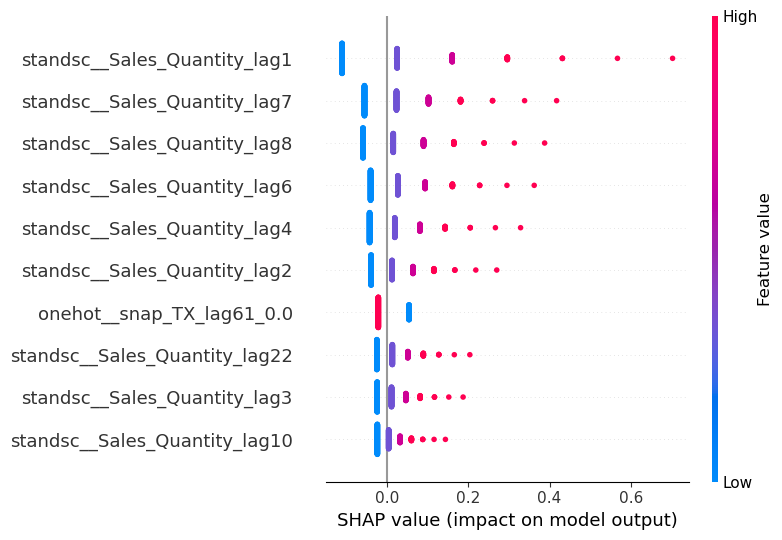

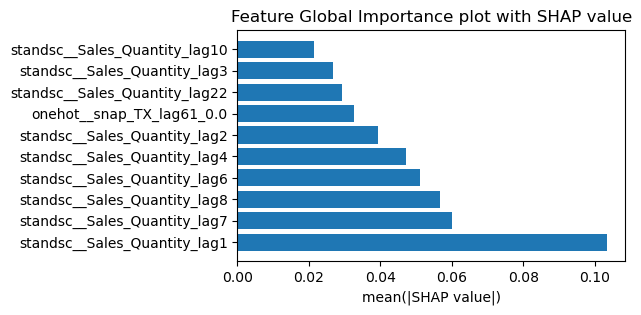

In [51]:
import shap

# shap global importance
shap.initjs() 

preprocessor = loaded_model.named_steps["preprocess"]
model = loaded_model.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)
explainer = shap.LinearExplainer(model, 
                                 X_test_transformed,
                                 feature_names= feature_list)


shap_values = explainer(X_test_transformed)

shap_summary= np.mean(np.abs(shap_values.values),axis=0)
sorted_indices= np.argsort(shap_summary)[::-1]
top_ftr_indices= sorted_indices[:10]


shap.summary_plot(shap_values[:,top_ftr_indices], 
                  X_test_transformed[:,top_ftr_indices],feature_names = feature_list[top_ftr_indices])


plt.figure(figsize=(5,3))
plt.barh(feature_list[top_ftr_indices],shap_summary[top_ftr_indices])
plt.xlabel('mean(|SHAP value|)')
plt.title("Feature Global Importance plot with SHAP value")
plt.savefig("shap global feature importance.png", dpi=300,bbox_inches="tight")
plt.show()

Expected Value:0.7649117117418406


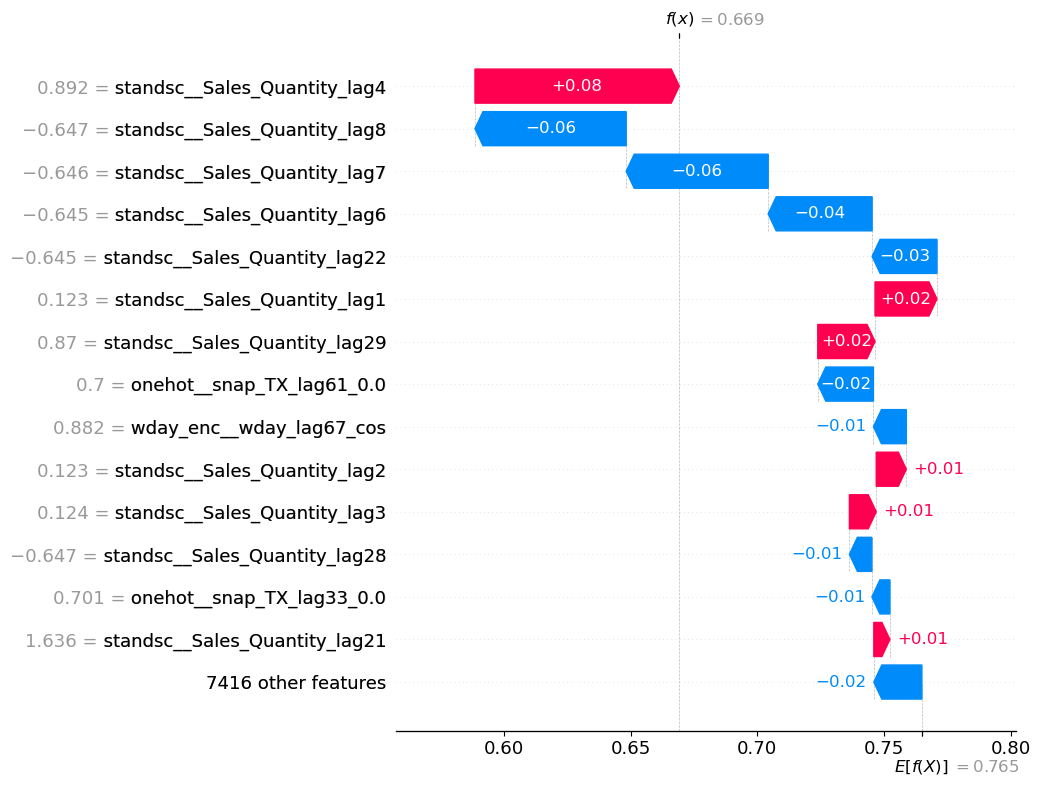

Expected Value:0.7649117117418406


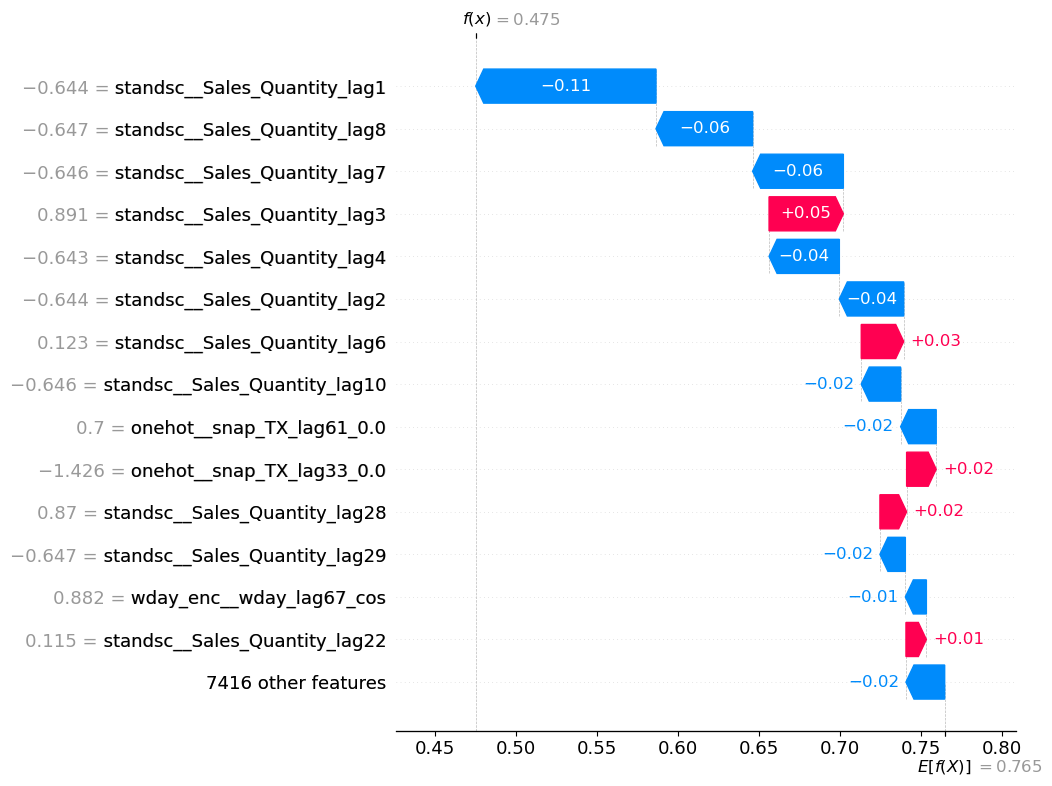

Expected Value:0.7649117117418406


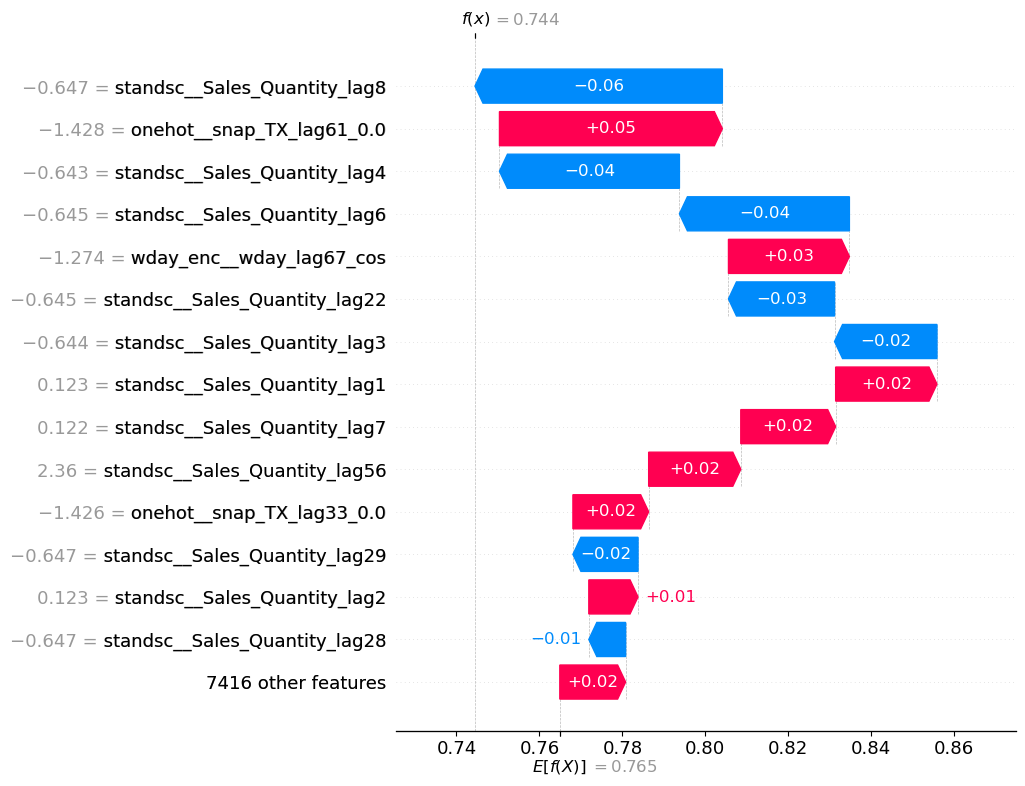

In [47]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

shap.initjs()


for i in [0, 100, 200]: 
   
   index = i # the index of the point to explain
   print(f"Expected Value:{explainer.expected_value}") 

   #plot force plot 
   #force= shap.force_plot(explainer.expected_value, shap_values.values[index,:], 
   #                       features = X_test_transformed[index,:],feature_names = feature_list)
   #shap.save_html(f"force_plot_data point{i}.html", force)
   #display(force)


   exp = shap.Explanation(
        values = shap_values.values[index,:],
        base_values = explainer.expected_value,
        data = X_test_transformed[index,:],
        feature_names = feature_list
    ) 

   shap.plots.waterfall(exp, max_display=15)  
   shap.plots.waterfall(exp, max_display=15, show=False)
   plt.savefig(f"waterfall_plot_{i}.png",
                dpi=300,
                bbox_inches="tight")
   plt.close()